In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
from tensorflow.keras.models import Model

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [3]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.0,986.821602,0,0.000692,1.0,1.109330,0.795094,1,986.821602,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.0,1754.958804,0,0.000495,1.0,1.203289,4.415985,4,7019.835216,1


In [4]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,season_factor,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,1.039557e+00,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,1.610565e-01,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,8.000000e-01,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,1.000000e+00,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,1.000000e+00,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,1.000000e+00,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,1.500000e+00,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   sale_id                 1040200 non-null  object 
 1   sale_date               1040200 non-null  object 
 2   store_id                1040200 non-null  object 
 3   product_id              1040200 non-null  object 
 4   quantity                1040200 non-null  int64  
 5   product_name            1040200 non-null  object 
 6   launch_date             1040200 non-null  object 
 7   price                   1040200 non-null  int64  
 8   store_name              1040200 non-null  object 
 9   city                    1040200 non-null  object 
 10  category_id             1040200 non-null  object 
 11  category_name           1040200 non-null  object 
 12  sales_amount            1040200 non-null  int64  
 13  invalid_launch_flag     1040200 non-null  bool   
 14  pr

In [6]:
df.describe(include='object')

,sale_id,sale_date,store_id,product_id,product_name,launch_date,store_name,city,category_id,category_name,country_norm_mapped,gdp_type
count,1040200,1040200,1040200,1040200,1040200,1040200,1040200,1040200,1040200,1040200,1040200,1040200
unique,1040200,1778,75,89,88,89,69,47,10,10,19,2
top,RW-18212,2022-08-10,ST-30,P-60,HomePod mini,2020-01-01,Apple Chadstone,Dubai,CAT-10,Accessories,united states,GDP_per_capita
freq,1,661,14113,11893,23442,496510,27851,55619,163849,163849,207728,1021241


In [7]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

df = df.sort_values(["store_id","sale_date"])

In [8]:
df["year"] = df["sale_date"].dt.year
df["month"] = df["sale_date"].dt.month

In [9]:
df_monthly = df.groupby([
    "store_id",
    "store_name",
    "country_norm_mapped",
    "year",
    "month"
]).agg({

    "sales_amount_realistic":"sum",
    "quantity_realistic":"sum",
    "price_realistic":"mean",

    "gdp_per_capita":"mean",
    "inflation_rate":"mean",
    "exchange_rate":"mean",
    "internet_usage_pct":"mean",

    "promo_flag":"mean"

}).reset_index()

In [10]:
df_monthly["date"] = pd.to_datetime(
    df_monthly[["year","month"]].assign(day=1)
)

In [11]:
df_monthly["month_sin"] = np.sin(2*np.pi*df_monthly["month"]/12)
df_monthly["month_cos"] = np.cos(2*np.pi*df_monthly["month"]/12)

In [12]:
df_monthly["gdp_growth"] = df_monthly.groupby("country_norm_mapped")["gdp_per_capita"].pct_change()

df_monthly["inflation_change"] = df_monthly.groupby("country_norm_mapped")["inflation_rate"].pct_change()

df_monthly["exchange_change"] = df_monthly.groupby("country_norm_mapped")["exchange_rate"].pct_change()

df_monthly["internet_growth"] = df_monthly.groupby("country_norm_mapped")["internet_usage_pct"].pct_change()

df_monthly.fillna(0,inplace=True)

In [13]:
features = [

"quantity_realistic",
"price_realistic",
"promo_flag",

"gdp_growth",
"inflation_change",
"exchange_change",
"internet_growth",

"month_sin",
"month_cos"

]

target = "sales_amount_realistic"

In [14]:
class Attention(Layer):

    def call(self, inputs):

        score = tf.nn.tanh(inputs)

        weights = tf.nn.softmax(score, axis=1)

        context = weights * inputs

        context = tf.reduce_sum(context, axis=1)

        return context

In [15]:
def build_model(n_features):

    inputs = Input(shape=(12, n_features))

    x = LSTM(128, return_sequences=True)(inputs)

    x = Attention()(x)

    x = Dense(64, activation="relu")(x)

    output = Dense(12)(x)

    model = Model(inputs, output)

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [16]:
def create_sequences(data, seq_len=12):

    X=[]
    y=[]

    for i in range(len(data)-seq_len-12):

        X.append(data[i:i+seq_len])

        y.append(data[i+seq_len:i+seq_len+12,0])

    return np.array(X),np.array(y)

In [17]:
stores = df_monthly["store_id"].unique()

store_results = {}

metrics_list = []

In [18]:
for store in stores:

    store_df = df_monthly[df_monthly["store_id"]==store]

    store_name = store_df["store_name"].iloc[0]
    country = store_df["country_norm_mapped"].iloc[0]

    store_df = store_df.sort_values("date")

    data = store_df[[target]+features]

    scaler = MinMaxScaler()

    scaled = scaler.fit_transform(data)

    X,y = create_sequences(scaled)

    if len(X) < 5:
        continue

    model = build_model(len(features)+1)

    model.fit(X,y,epochs=20,batch_size=16,verbose=0)

    pred_scaled = model(X,training=False).numpy()

    preds=[]
    actuals=[]

    for i in range(len(pred_scaled)):

        dummy = np.zeros((12,len(features)+1))
        dummy[:,0]=pred_scaled[i]

        inv = scaler.inverse_transform(dummy)[:,0]

        preds.extend(inv)
        actuals.extend(store_df[target].values[i+12:i+24])

    mae = mean_absolute_error(actuals,preds)
    mape = np.mean(np.abs((np.array(actuals)-np.array(preds))/actuals))*100
    r2 = r2_score(actuals,preds)

    accuracy = 100-mape

    metrics_list.append({
        "store":store_name,
        "country":country,
        "MAE":mae,
        "MAPE":mape,
        "R2":r2,
        "Accuracy":accuracy
    })

    store_results[store]=(model,scaler,store_df,store_name,country)

In [19]:
metrics_df = pd.DataFrame(metrics_list)

print(metrics_df)

                          store         country            MAE       MAPE  \
0            Apple Fifth Avenue   united states  335749.309271  16.341182   
1       Apple South Coast Plaza   united states  328545.618456  15.461978   
2               Apple Ala Moana   united states  433361.697851  14.944223   
3   Apple North Michigan Avenue   united states  384481.906325  16.419181   
4           Apple Walnut Street   united states  442793.261443  16.761067   
..                          ...             ...            ...        ...   
70          Apple Covent Garden  united kingdom  336583.913516  20.460197   
71          Apple Central World        thailand  140436.374328  17.244890   
72            Apple Beijing SKP           china  149331.491329  17.976153   
73          Apple Pioneer Place   united states  309609.501165  16.622550   
74    Apple Park Visitor Center   united states  304534.870531  13.611617   

          R2   Accuracy  
0   0.046696  83.658818  
1   0.038768  84.538022

In [20]:
future_dates = pd.date_range(
    start="2025-01-01",
    periods=12,
    freq="MS"
)

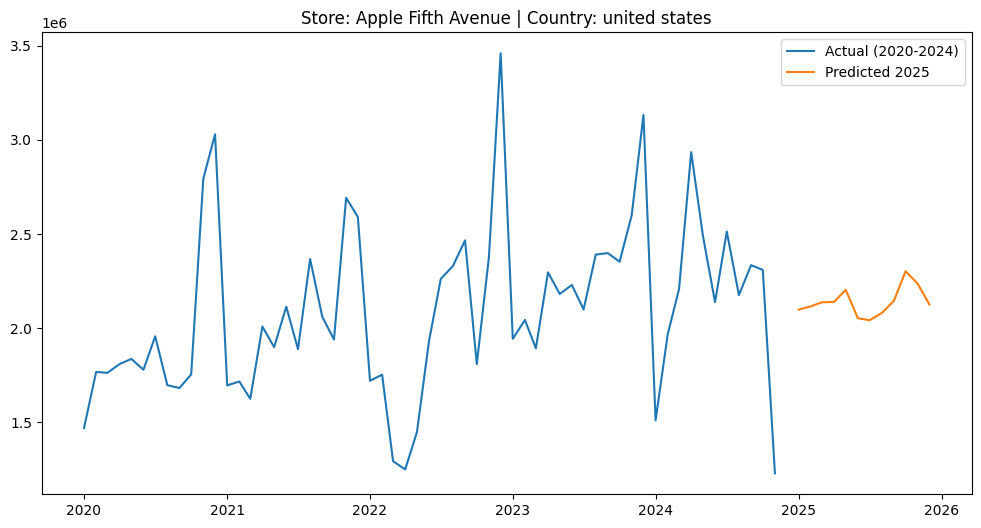

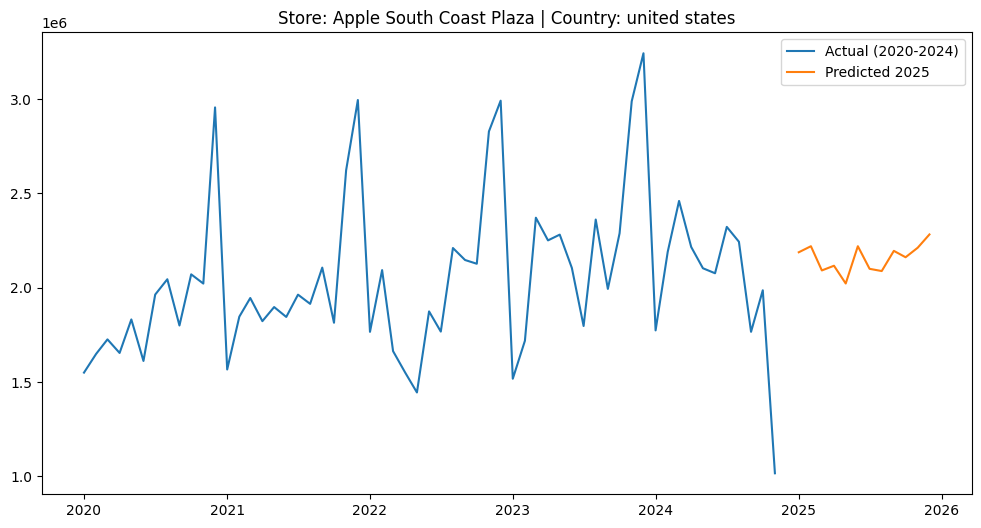

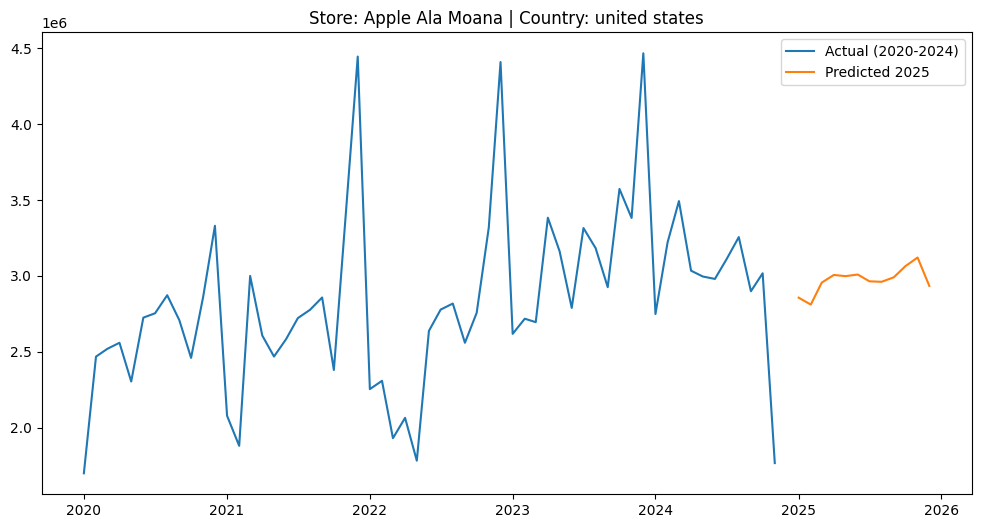

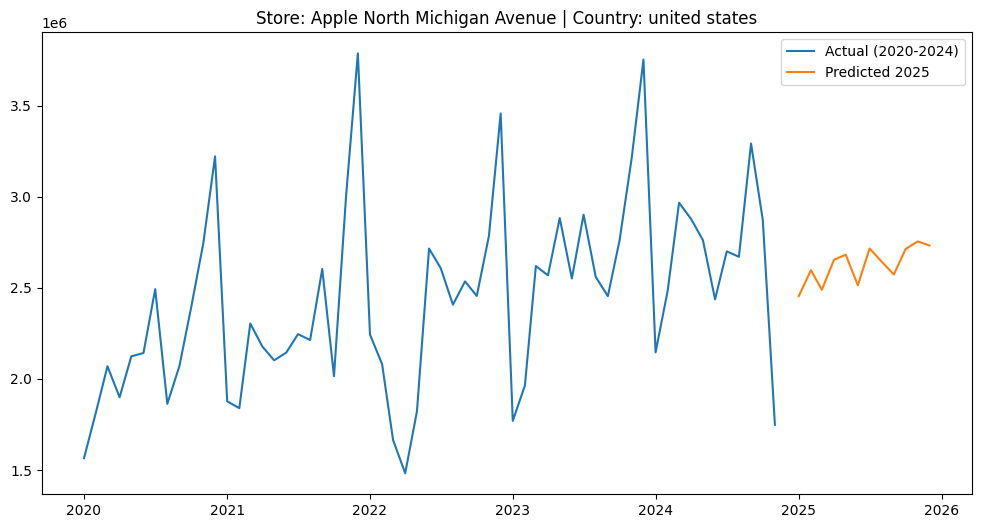

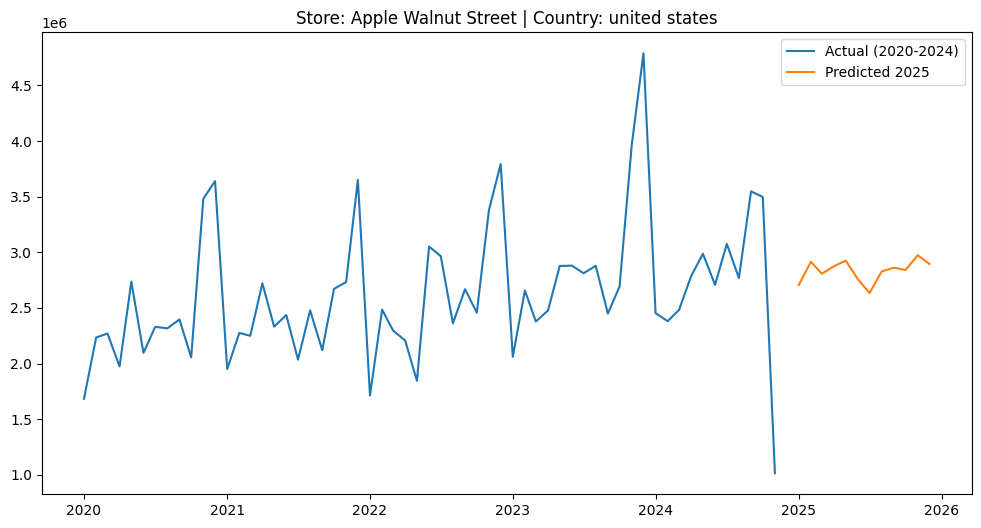

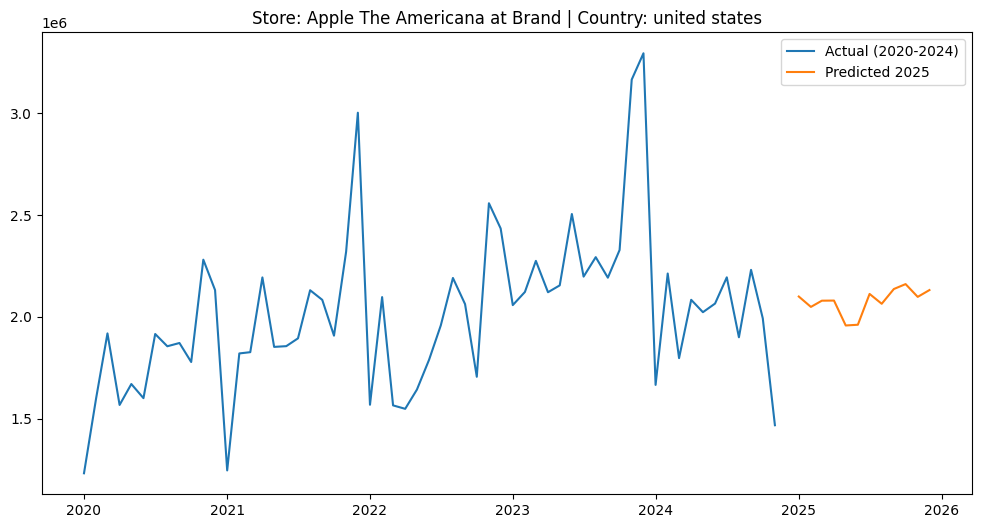

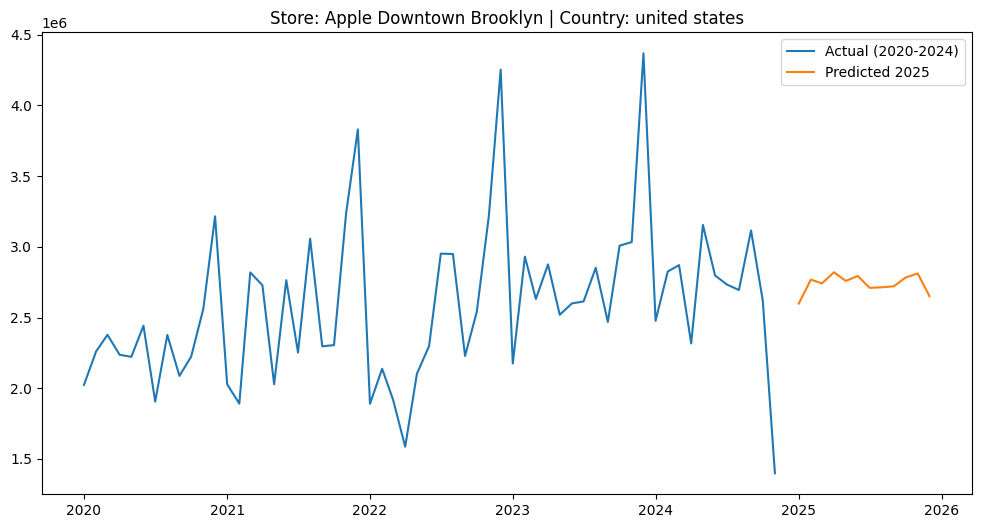

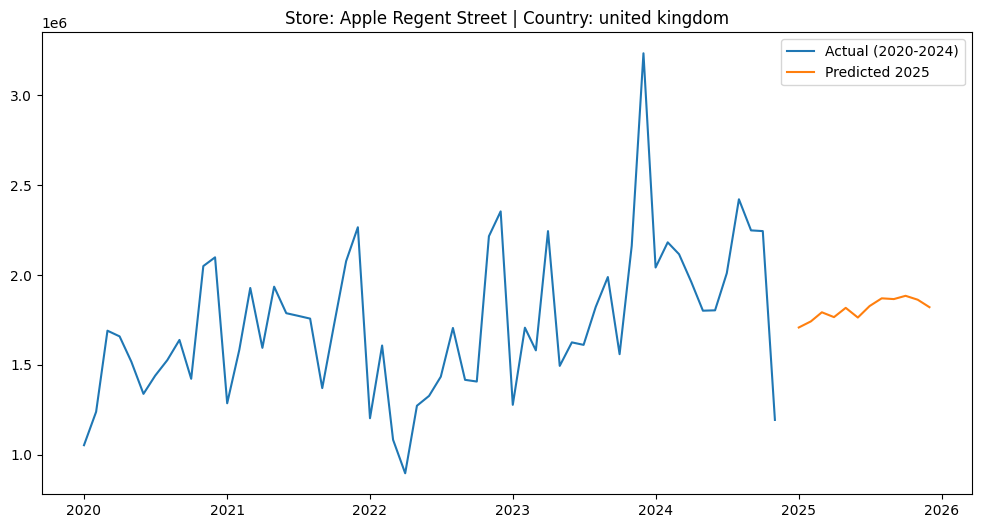

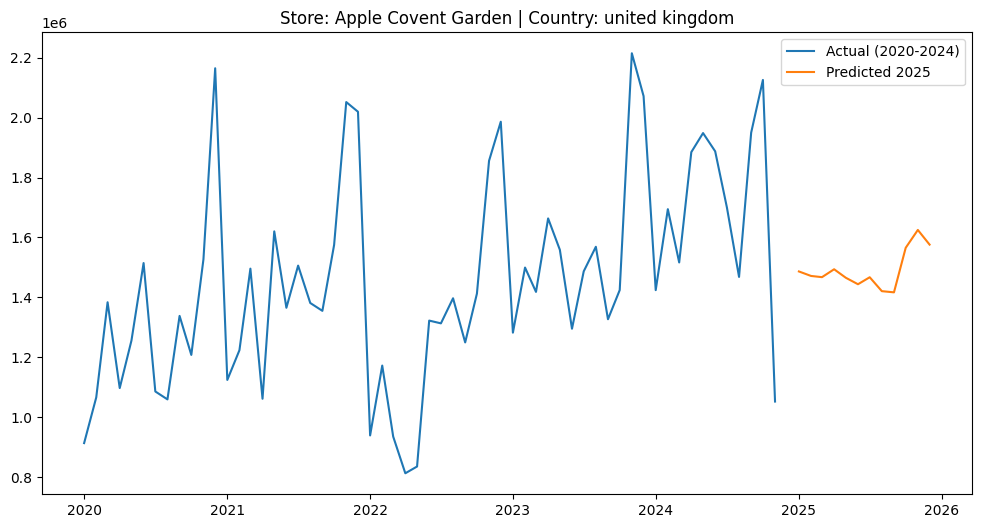

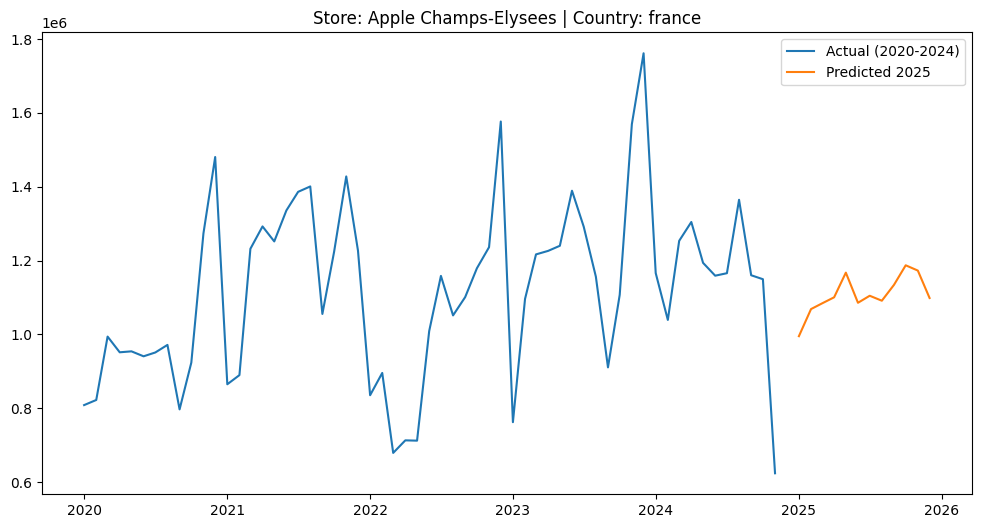

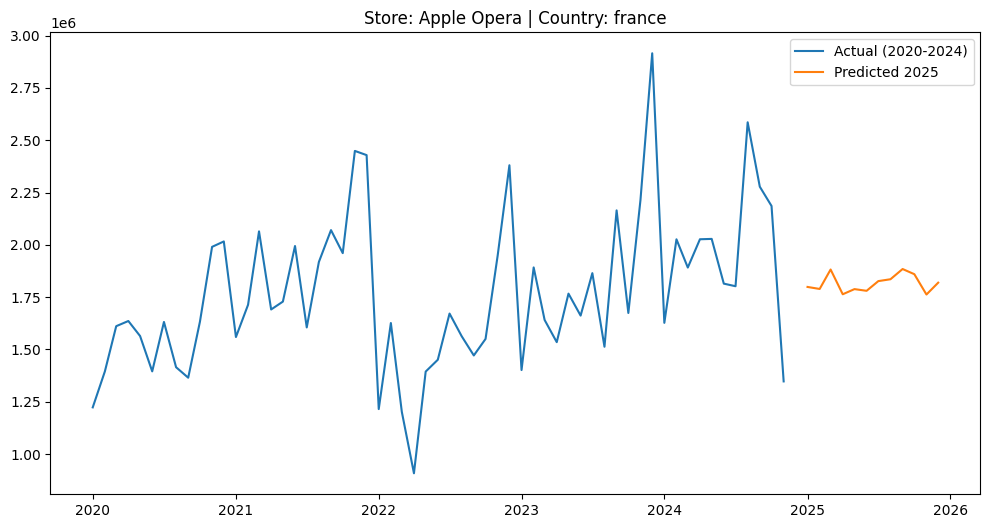

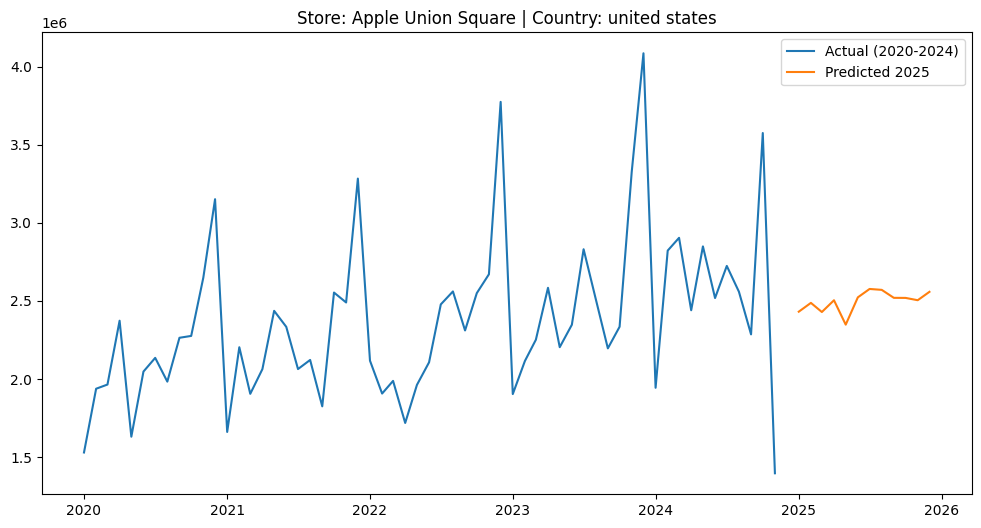

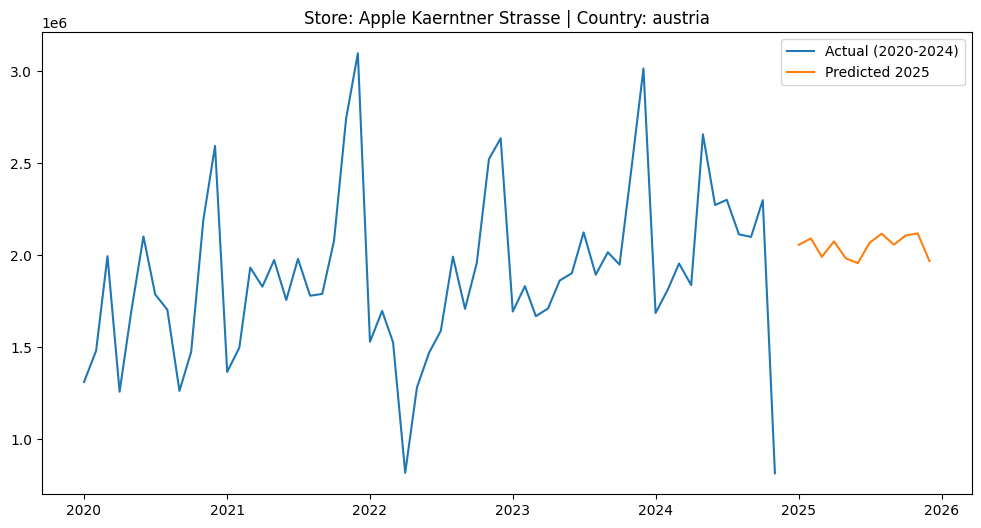

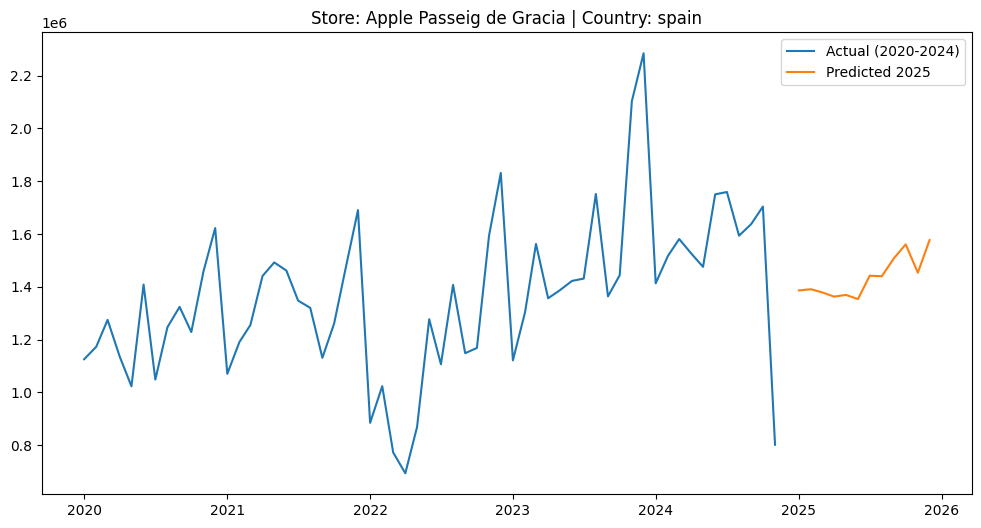

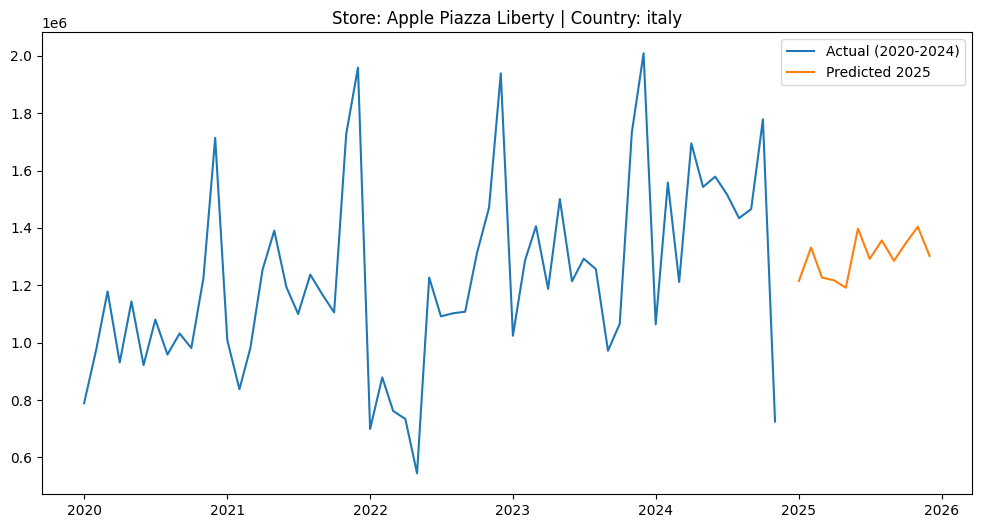

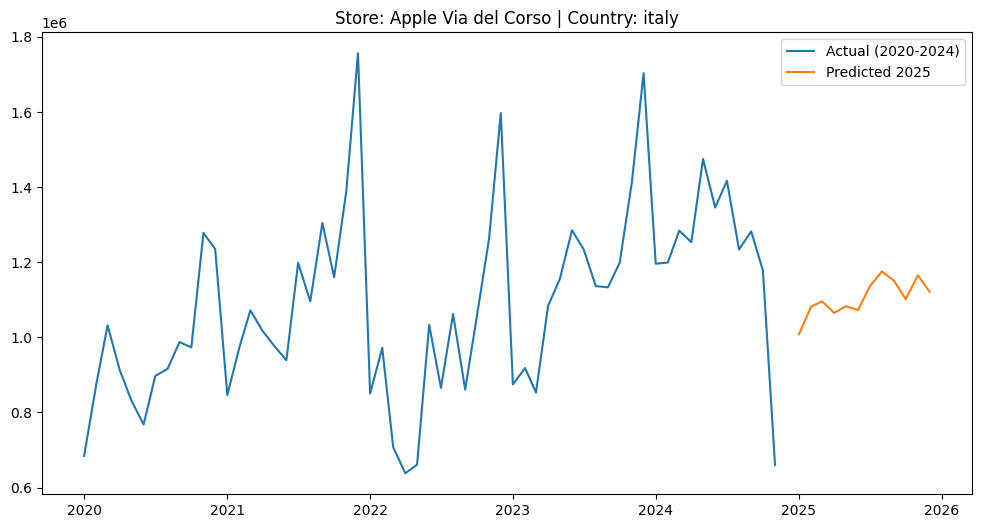

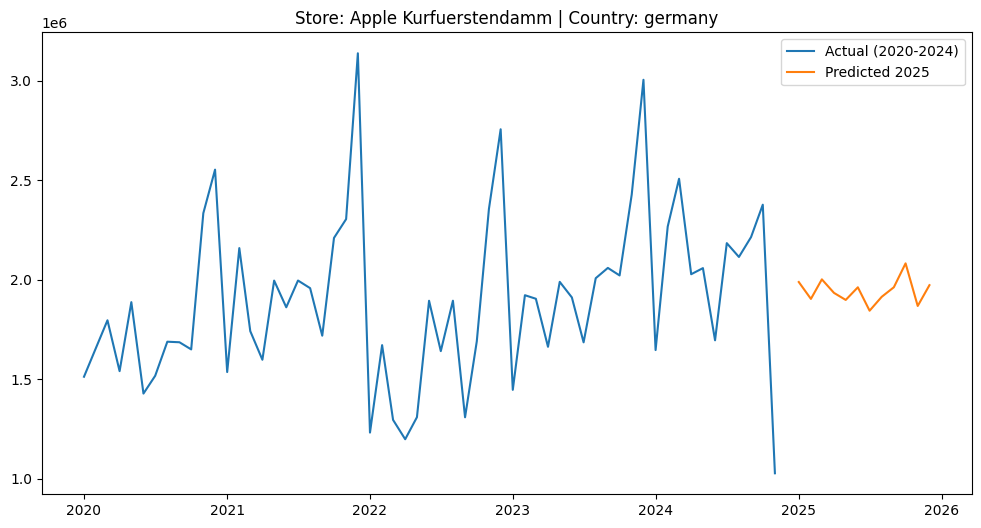

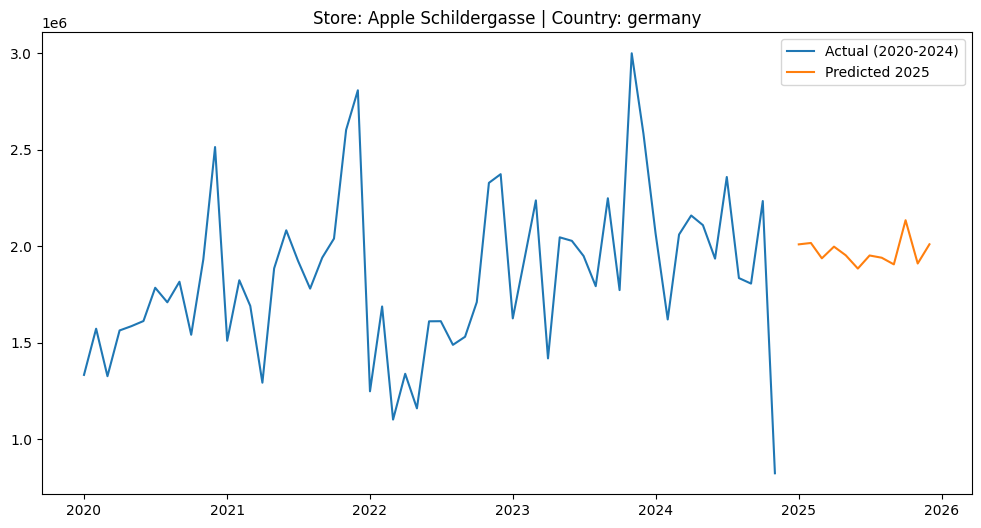

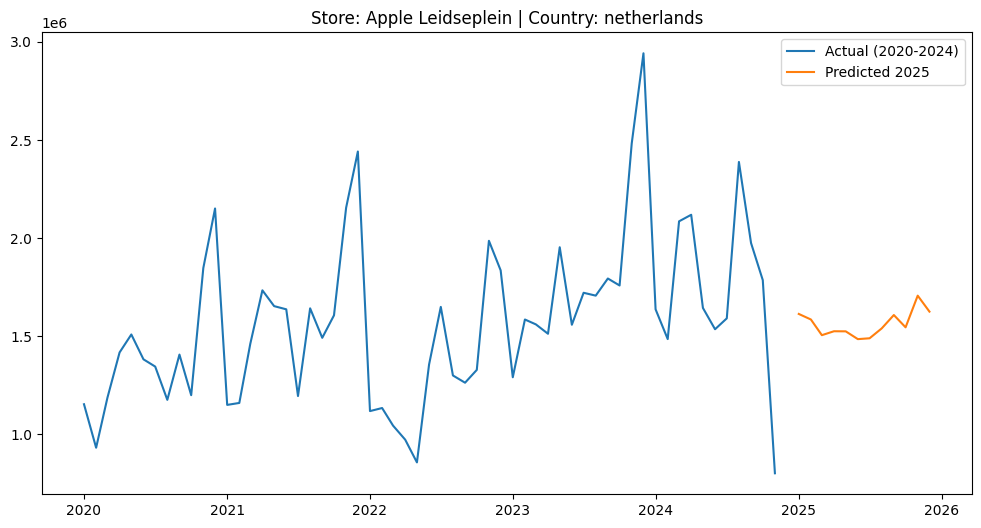

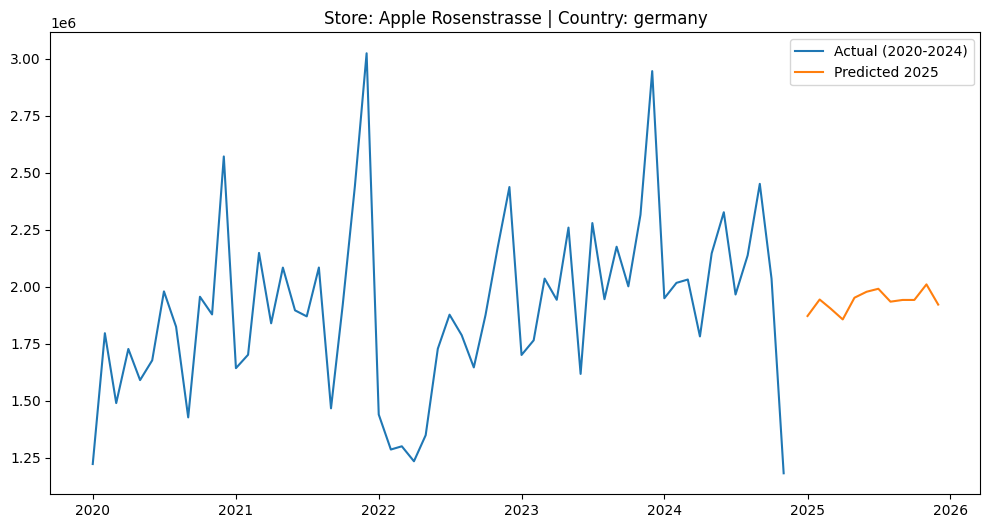

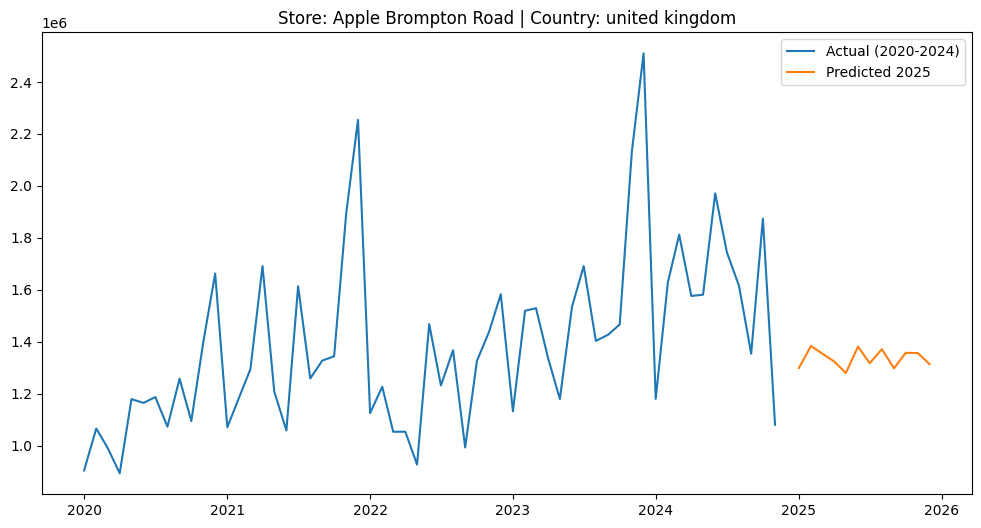

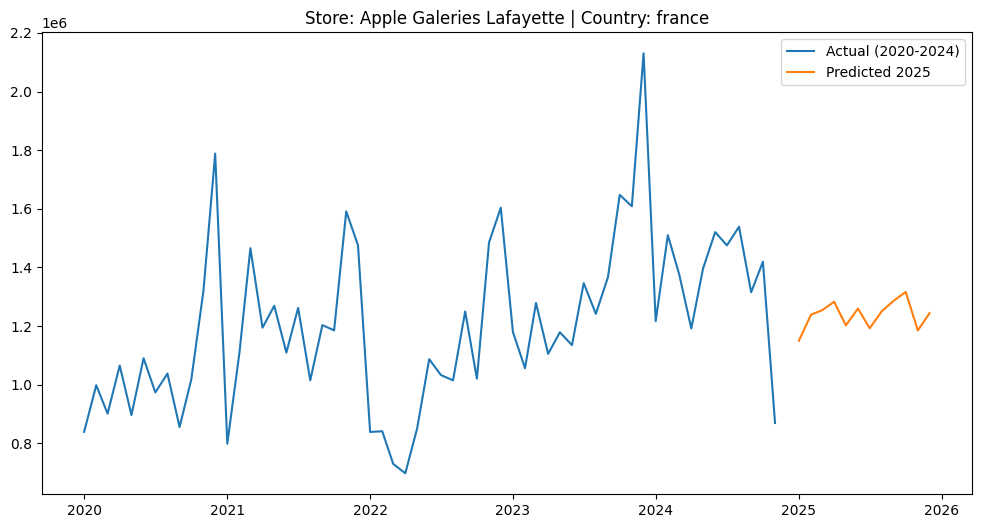

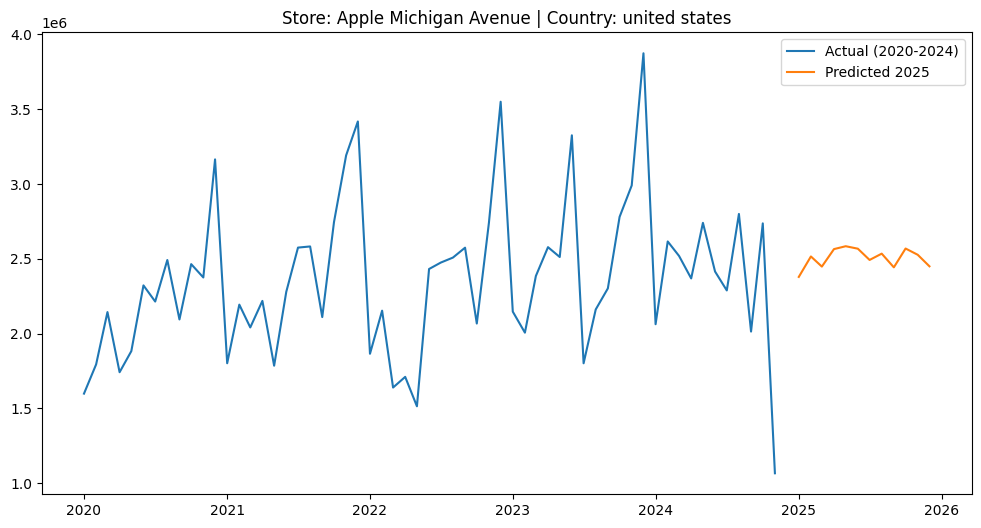

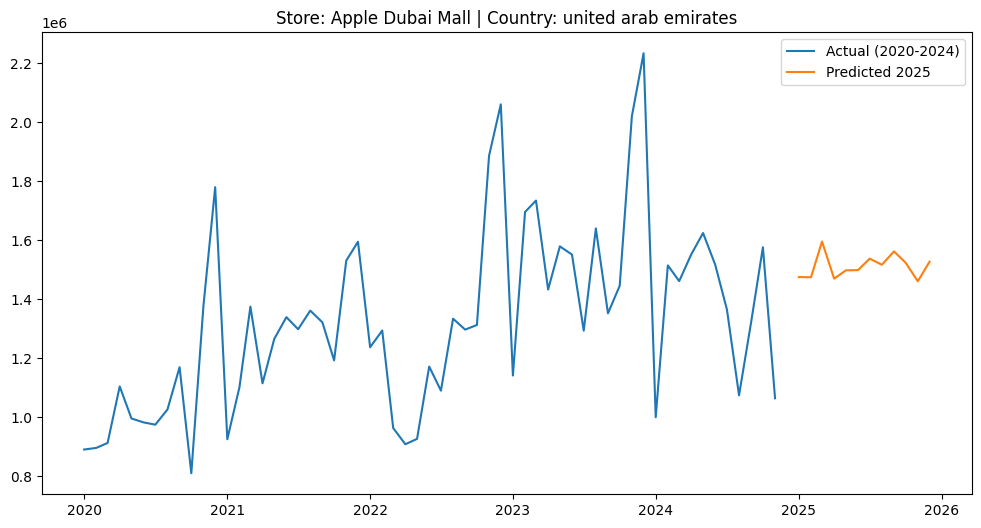

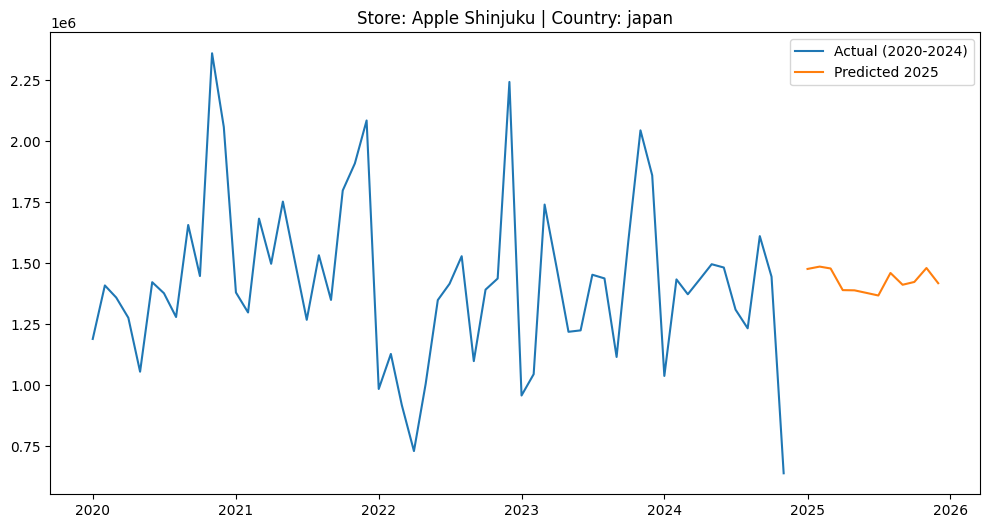

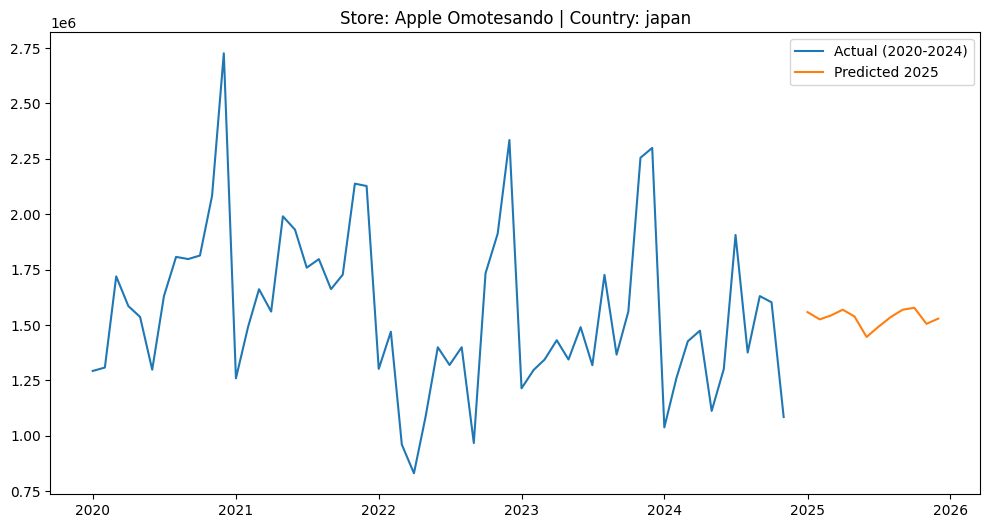

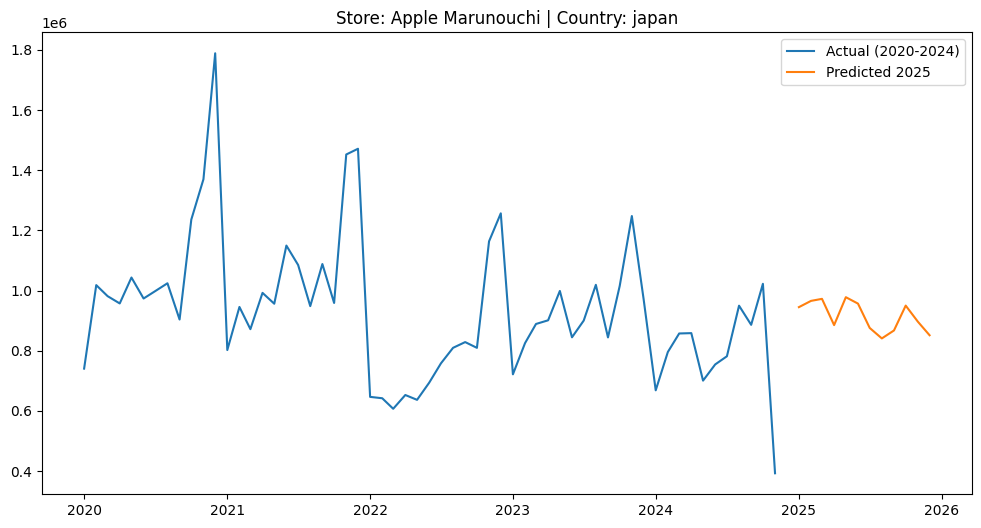

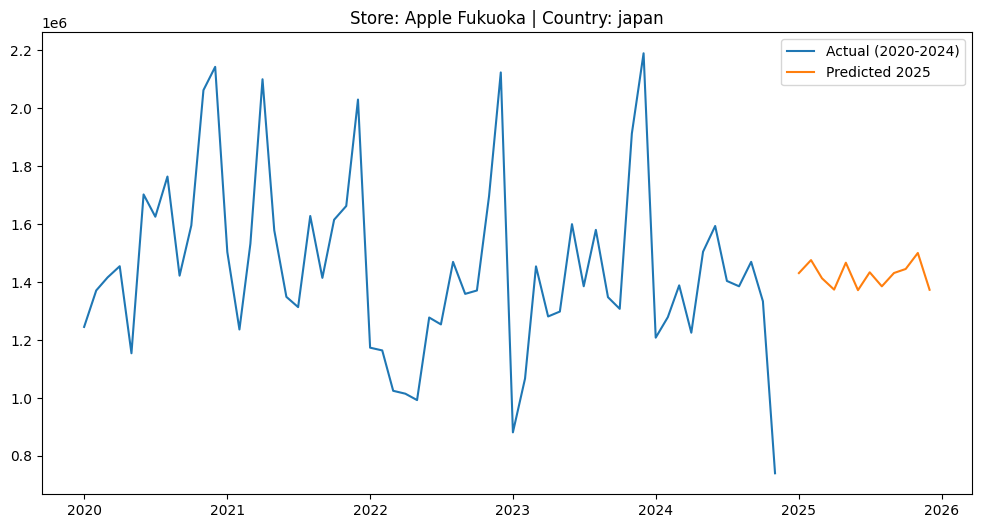

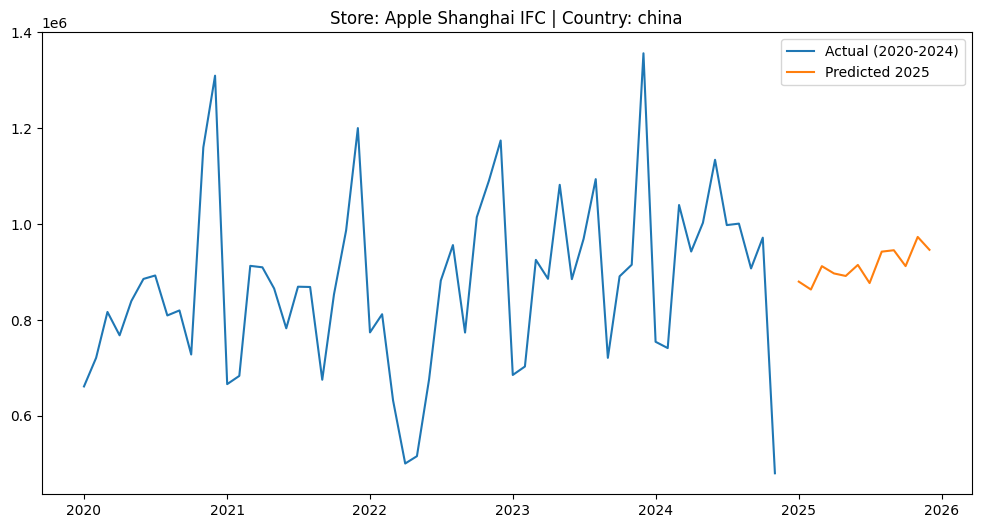

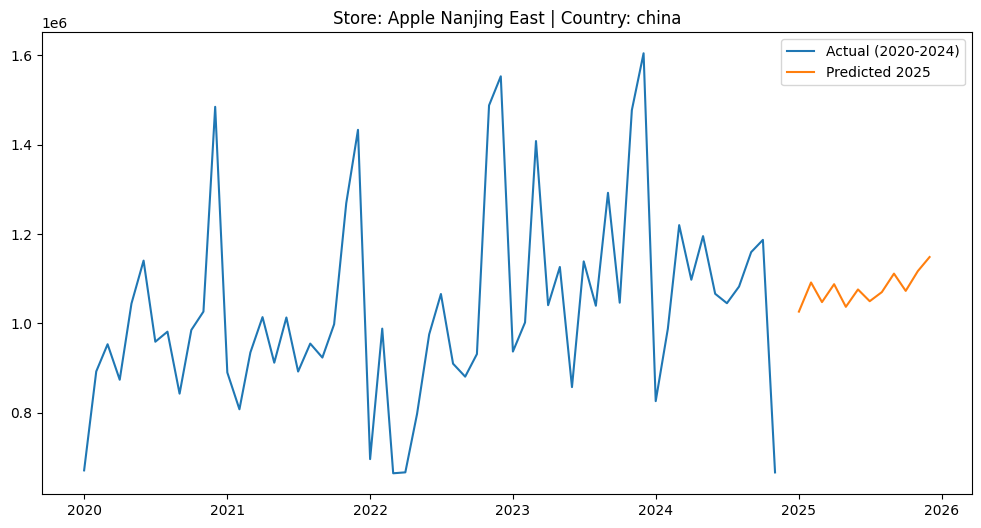

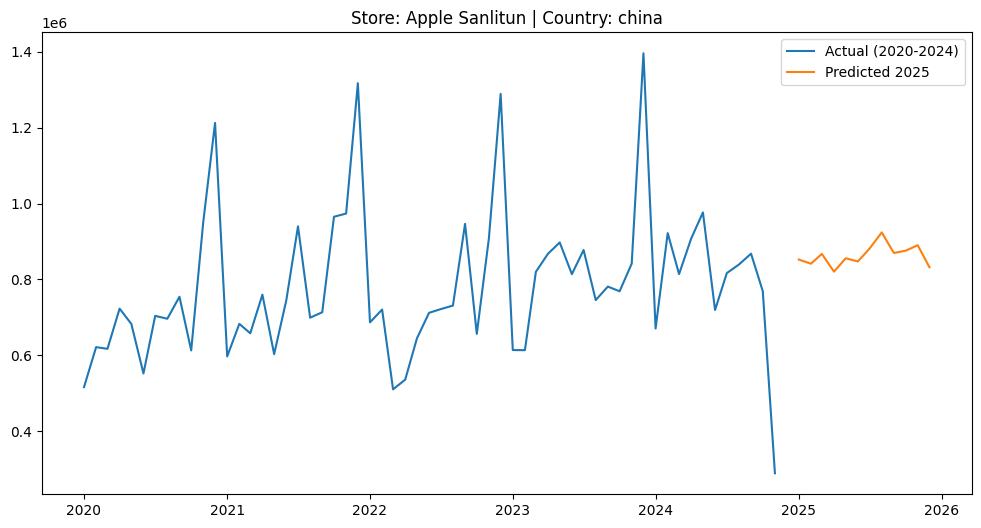

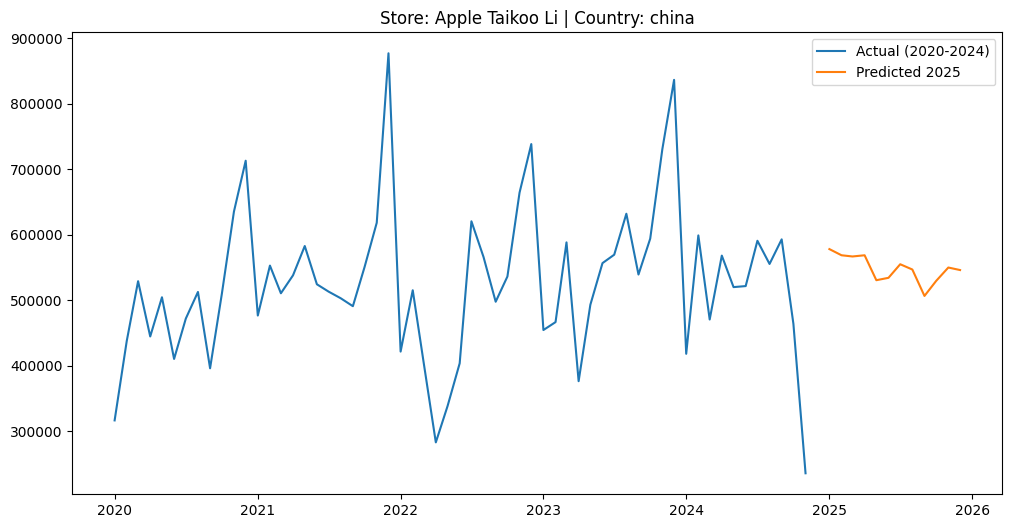

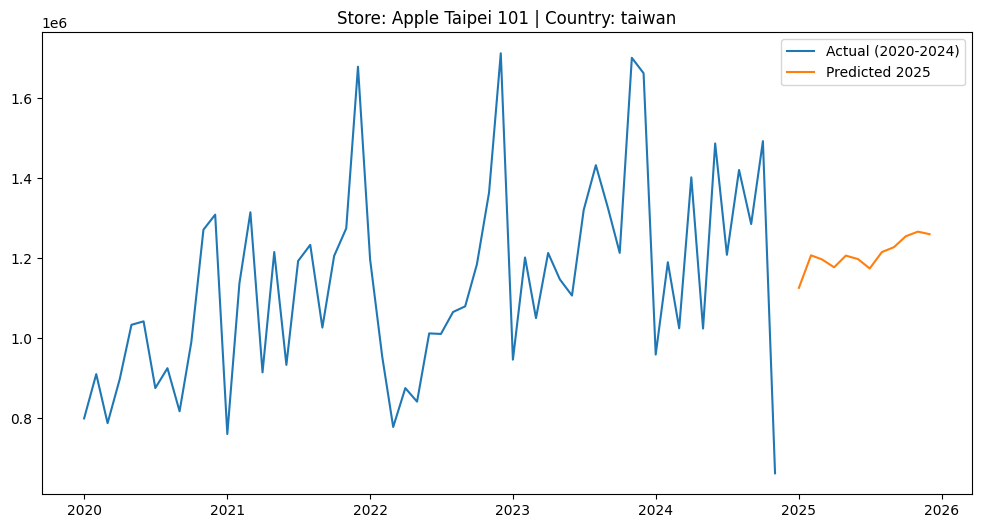

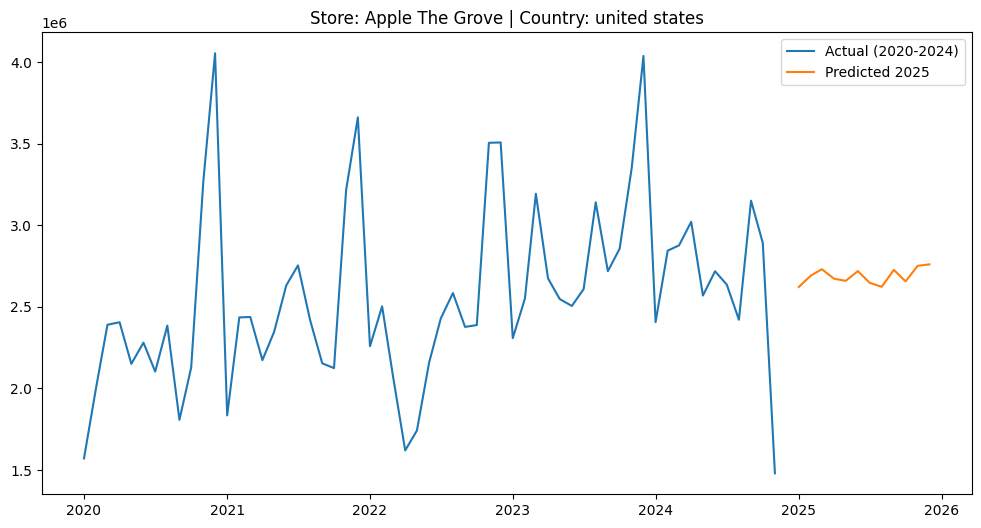

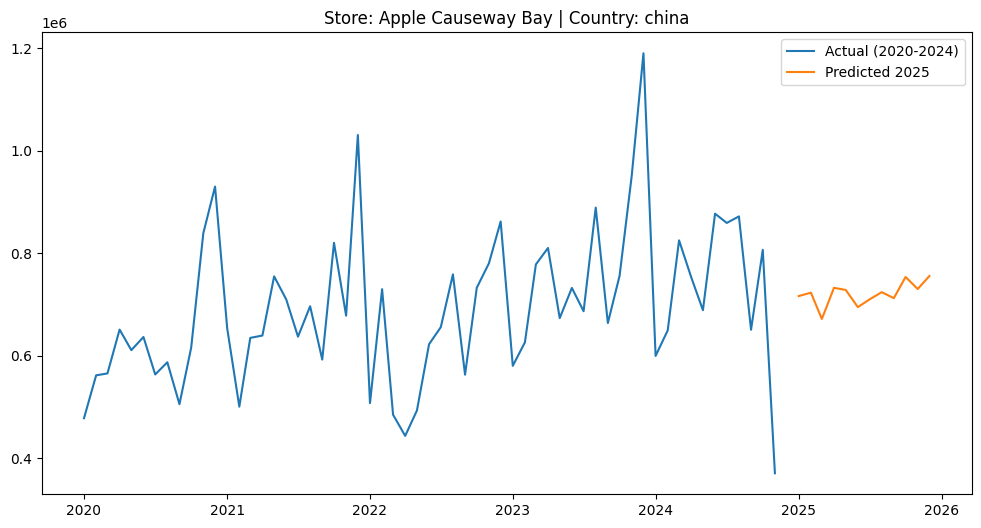

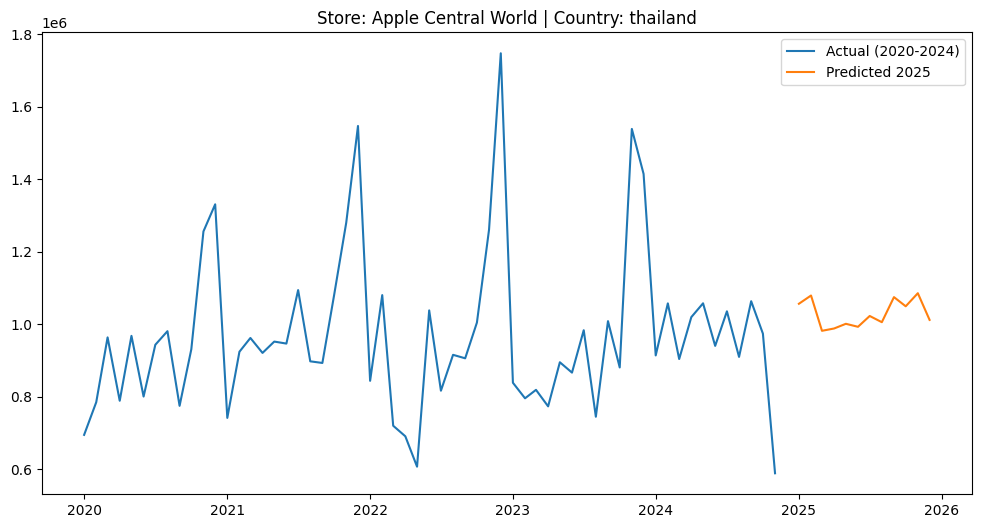

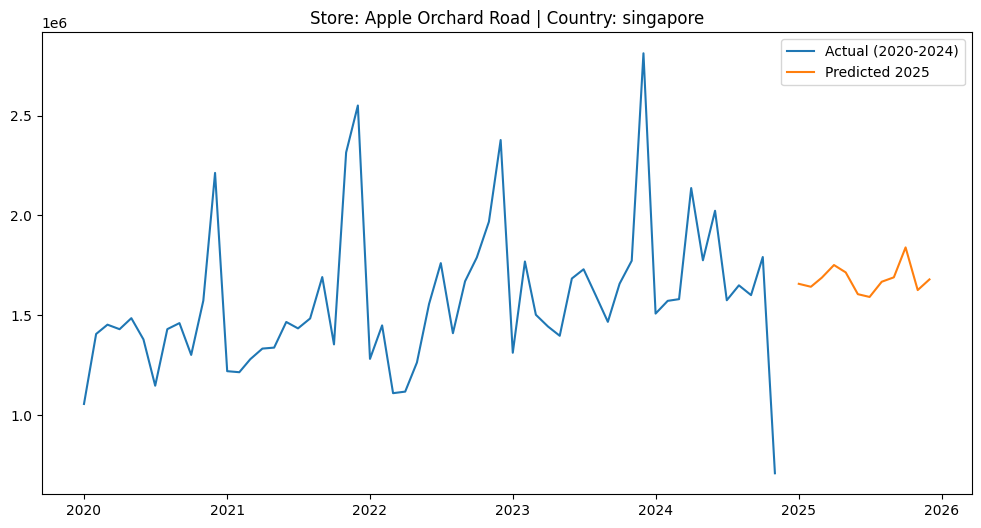

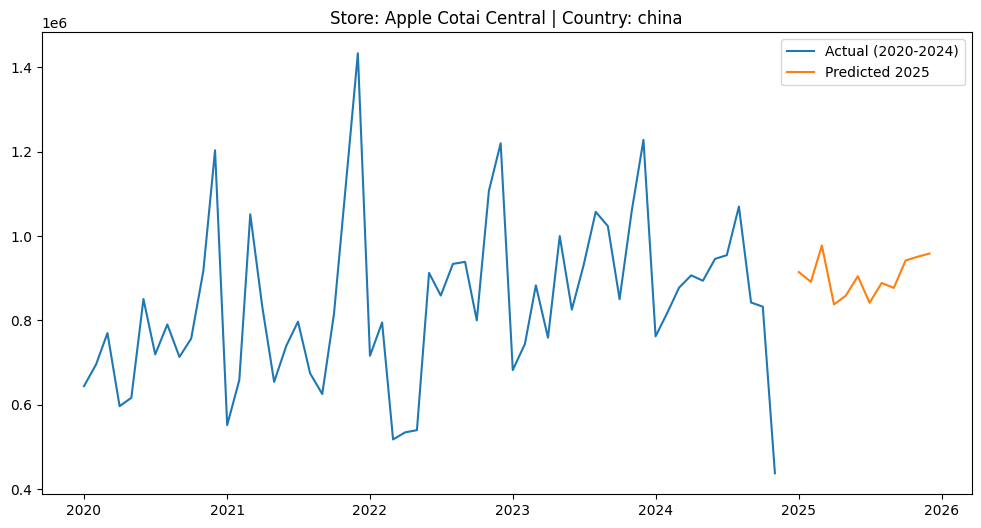

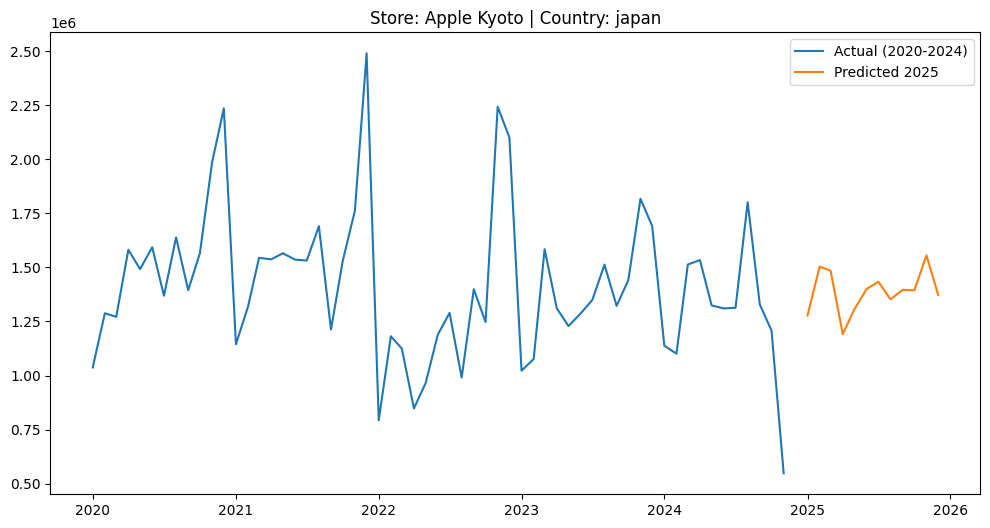

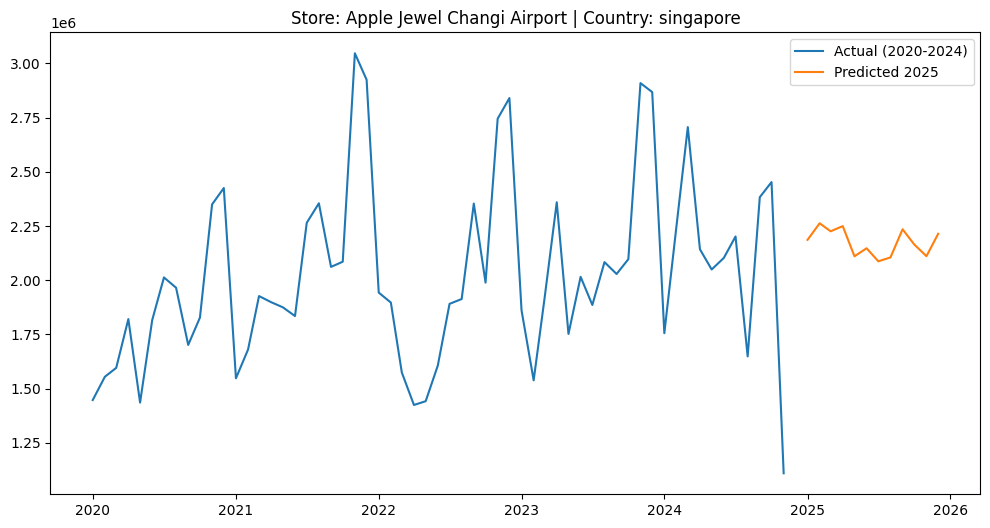

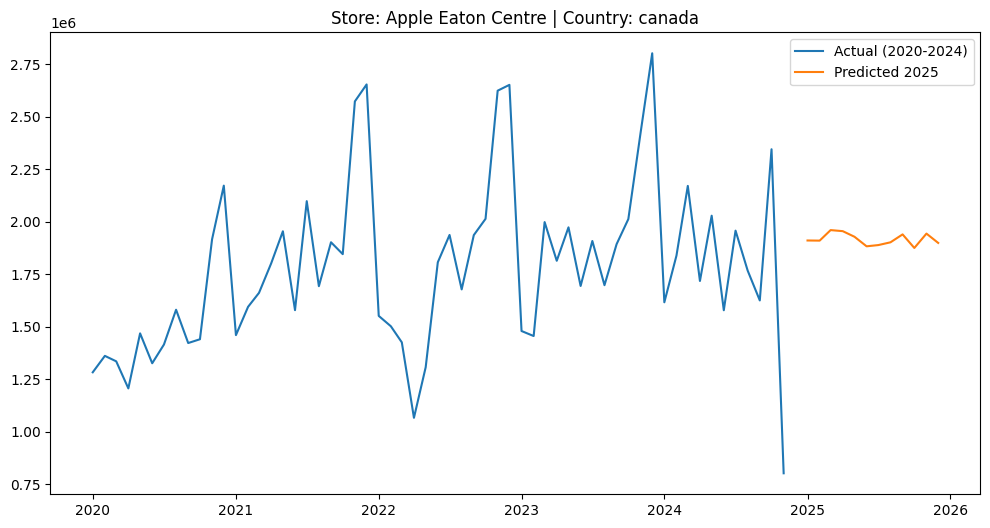

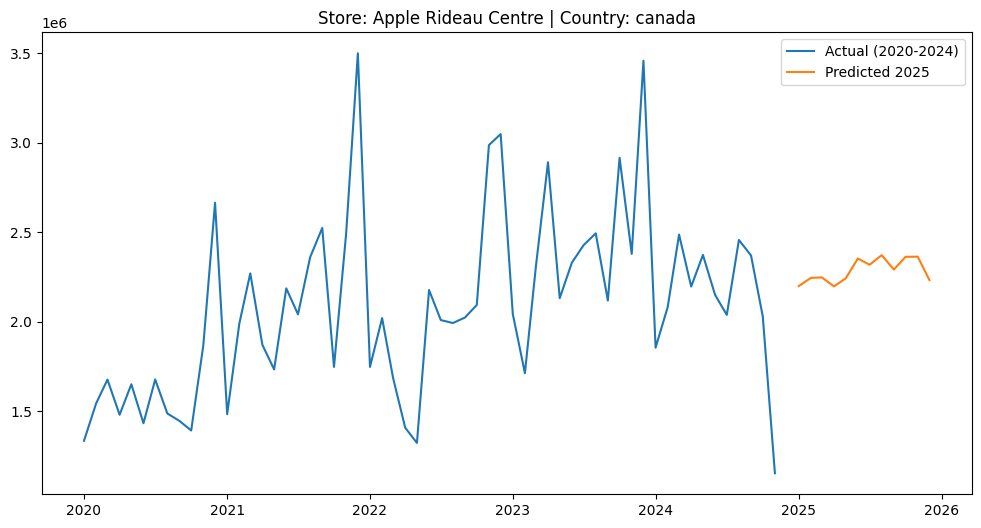

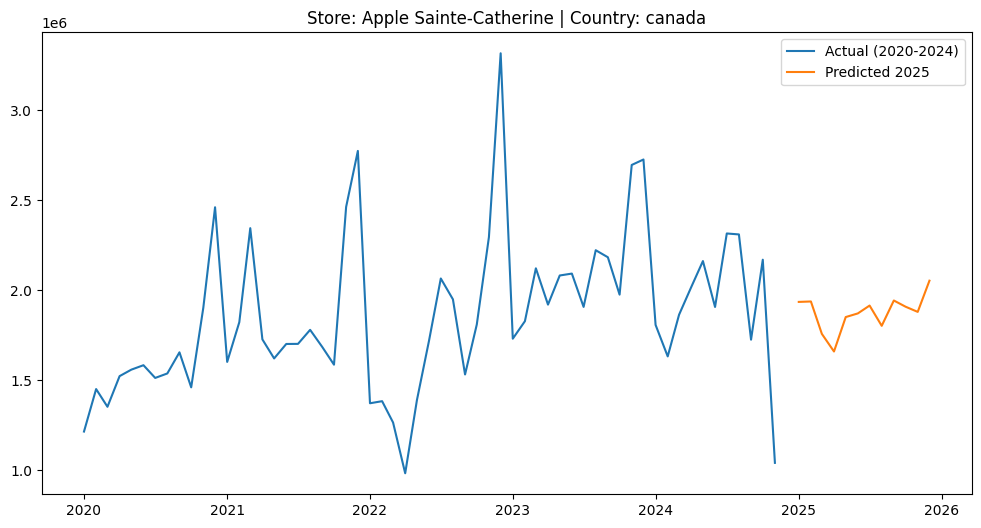

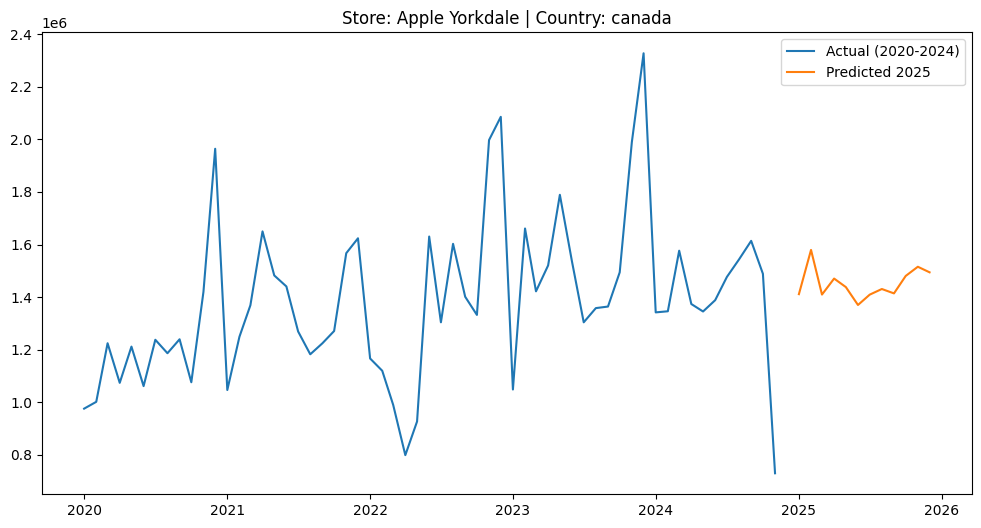

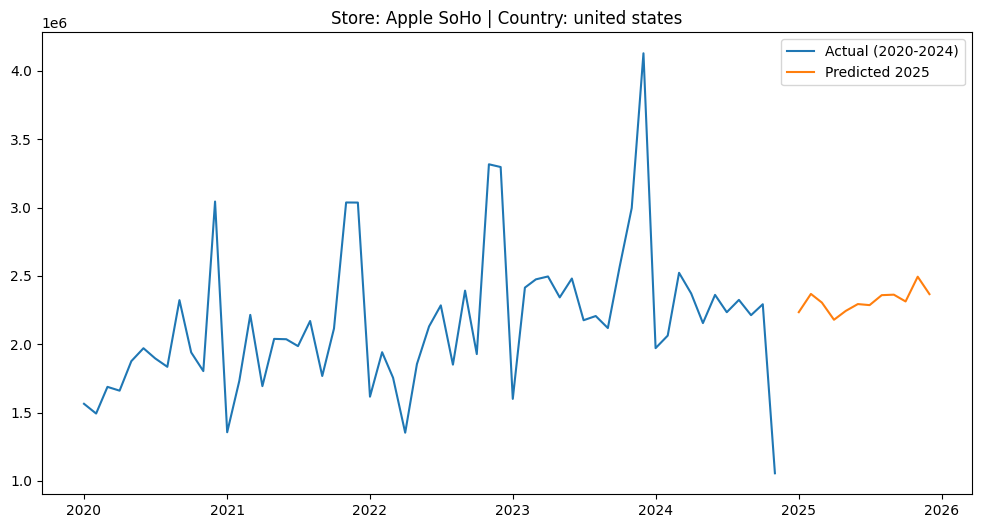

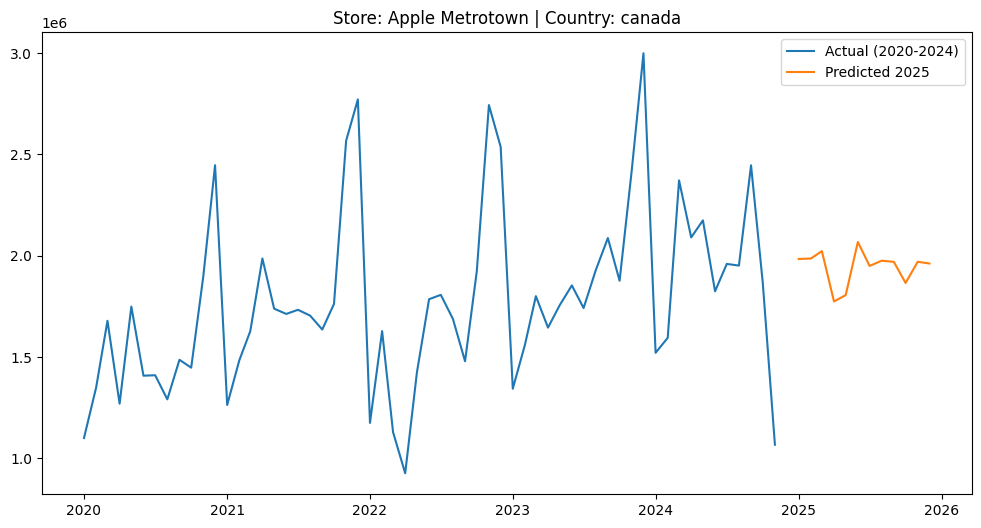

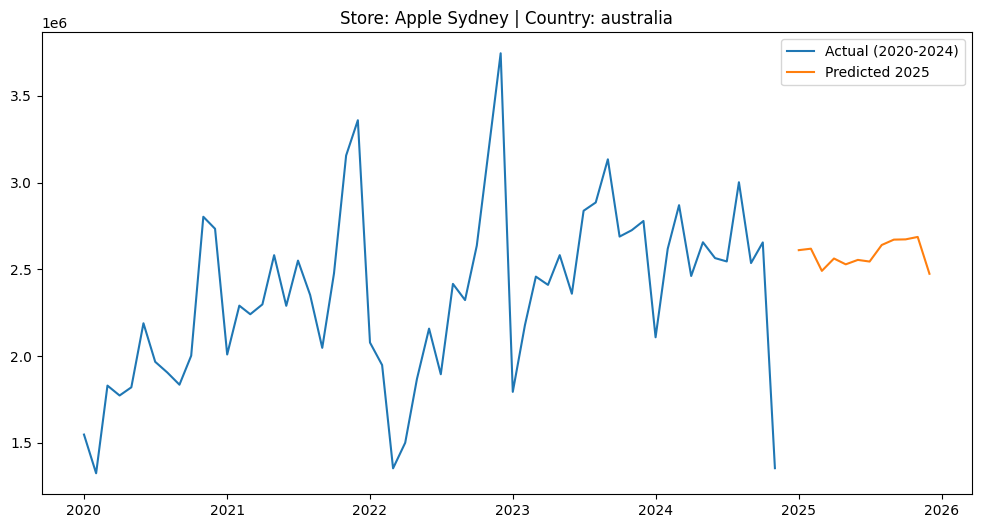

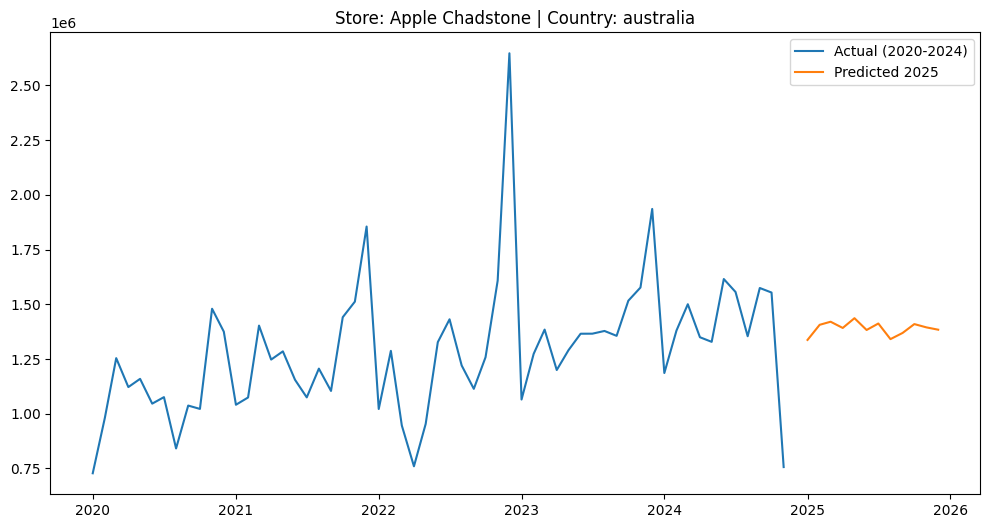

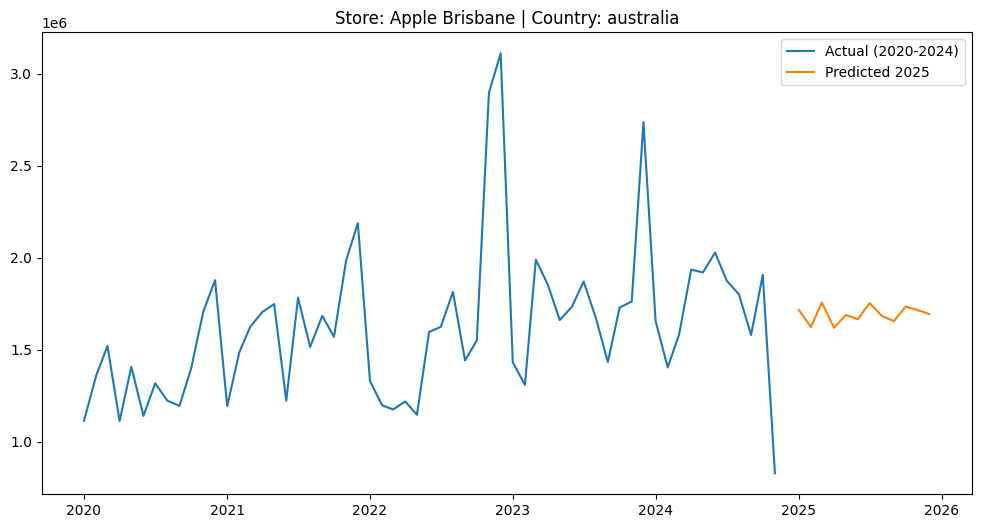

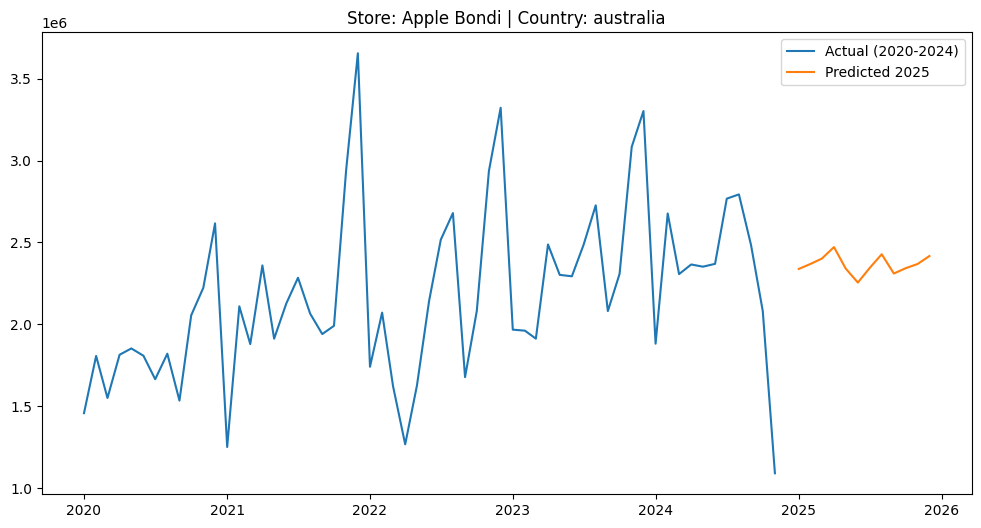

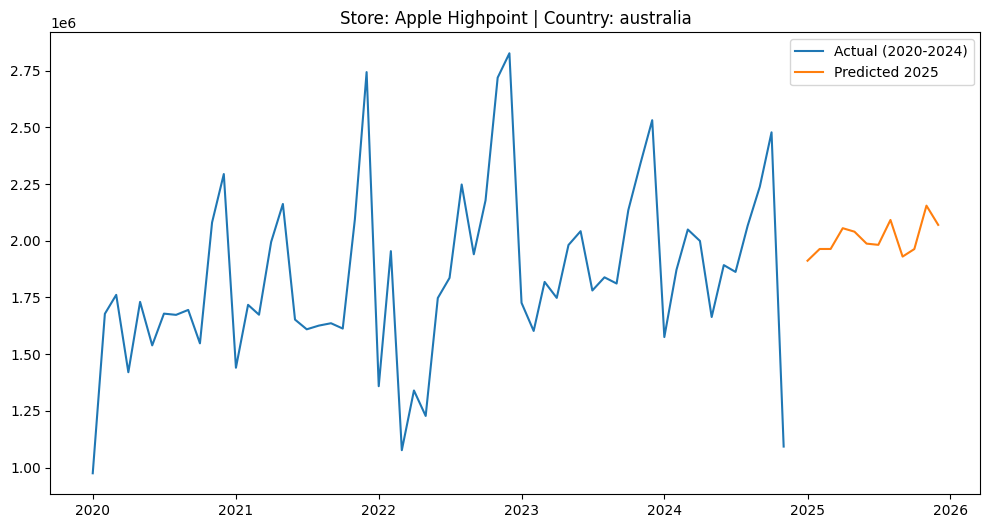

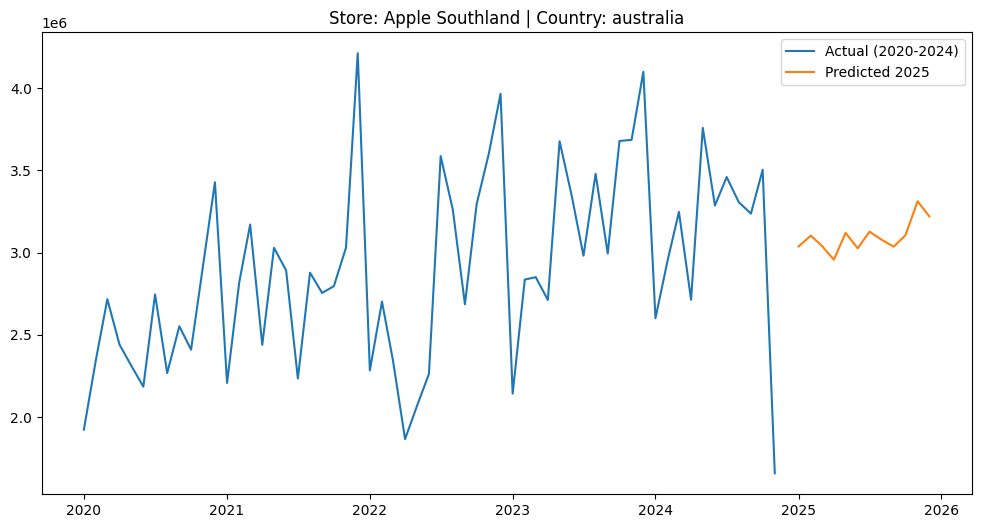

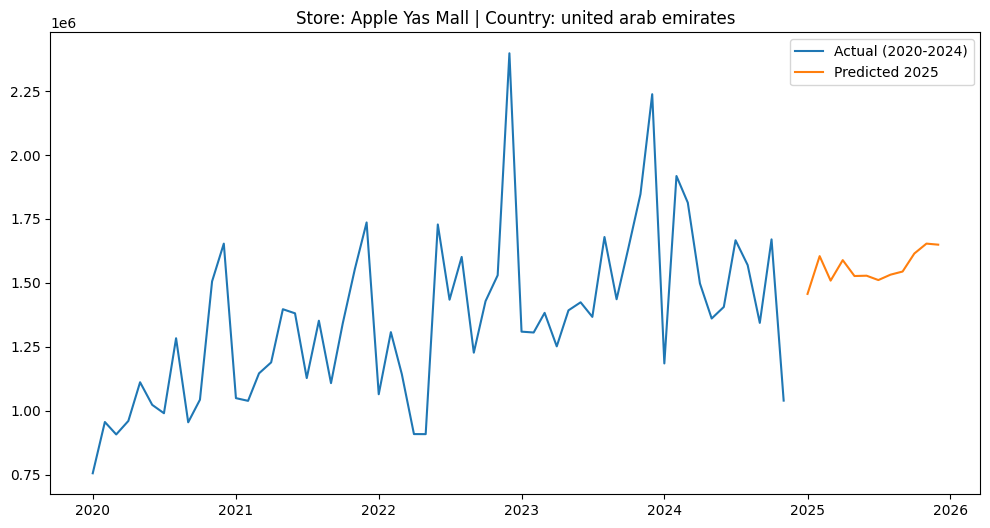

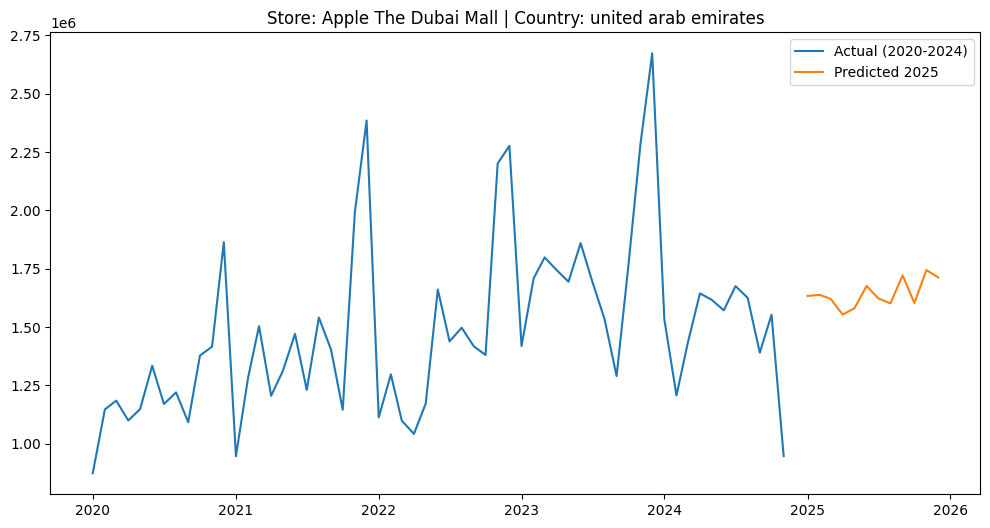

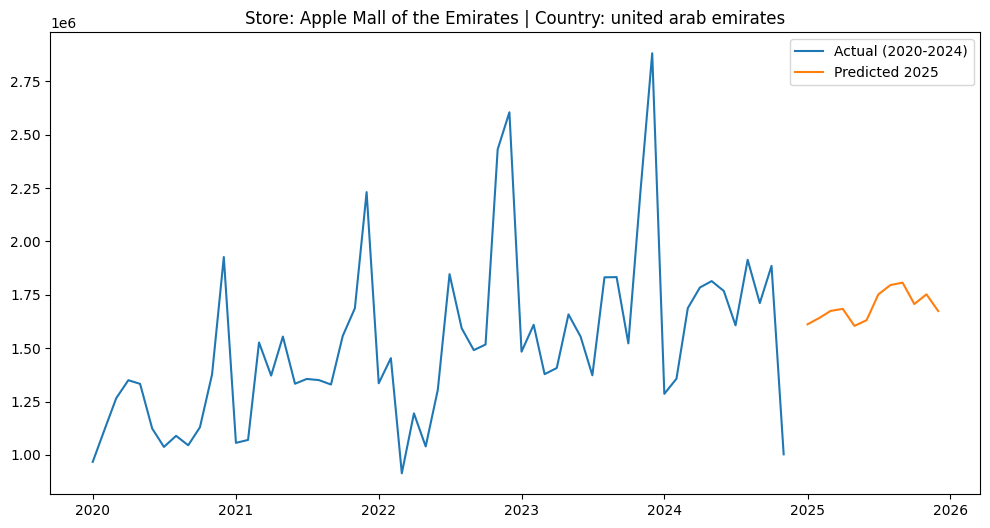

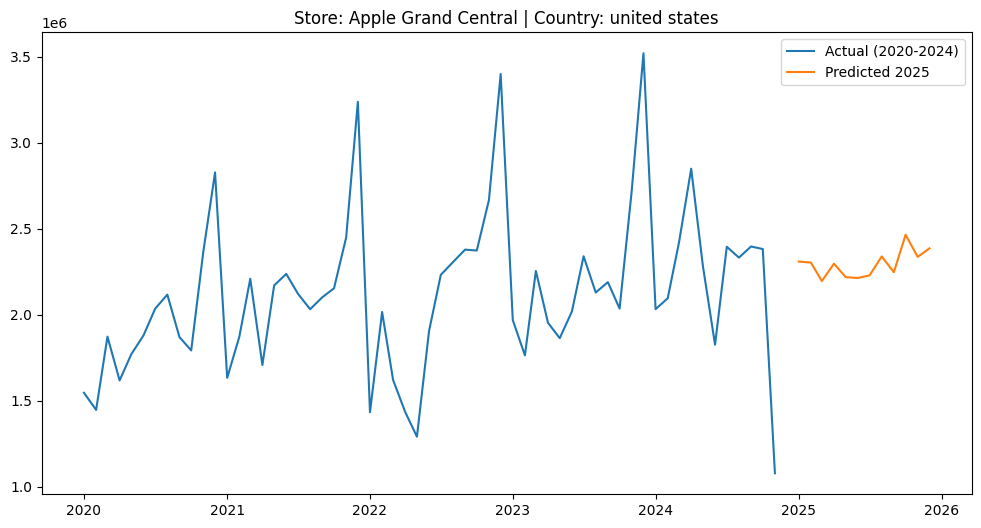

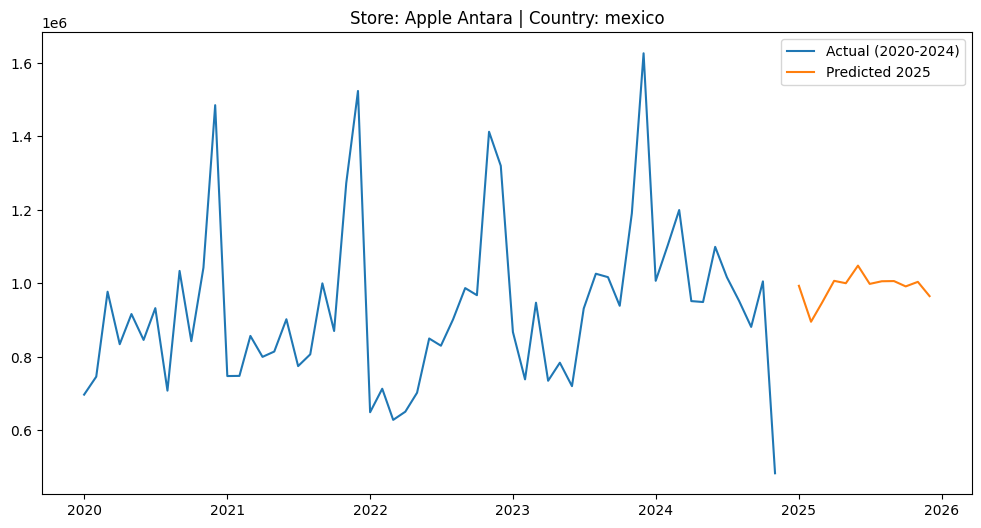

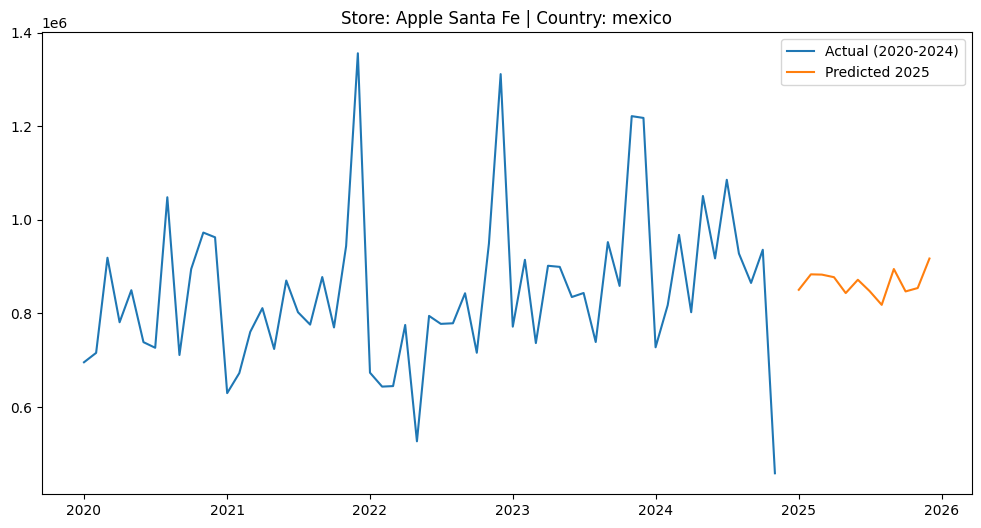

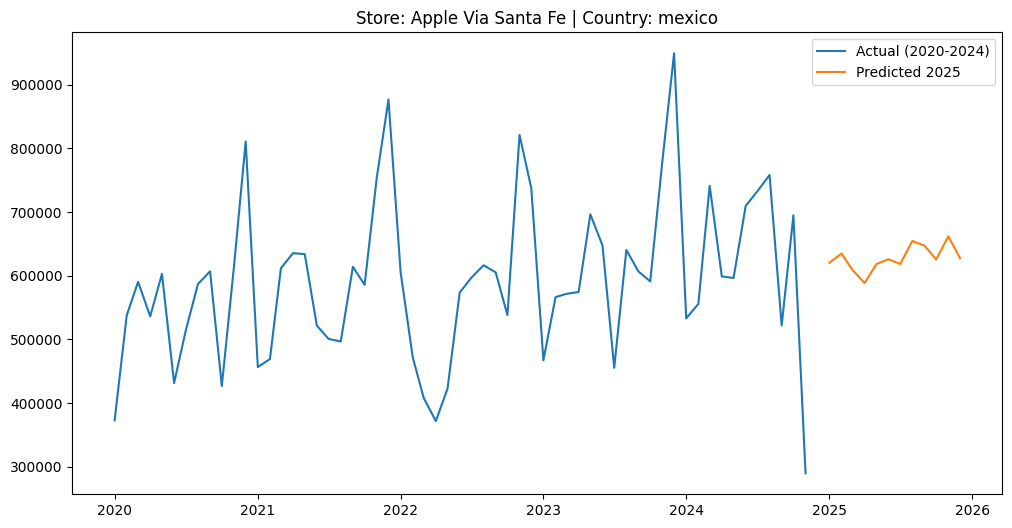

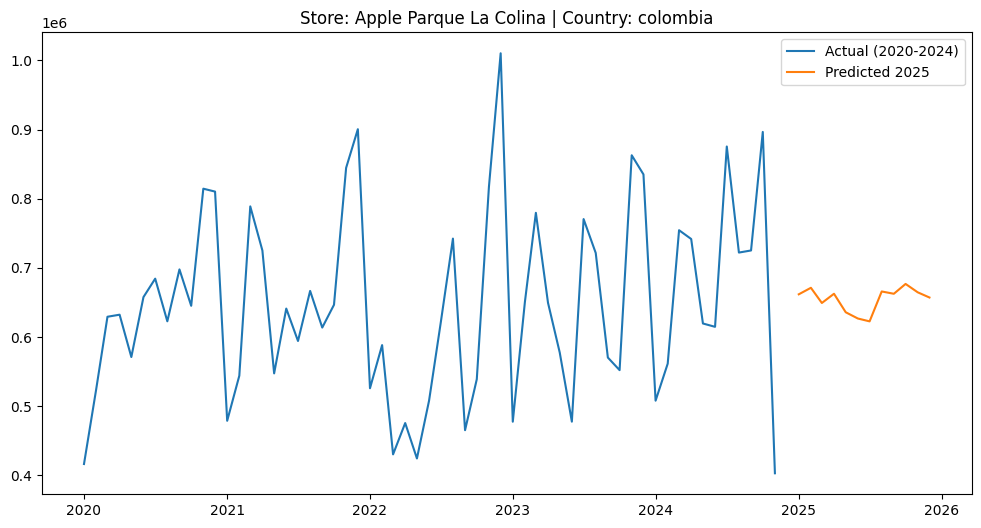

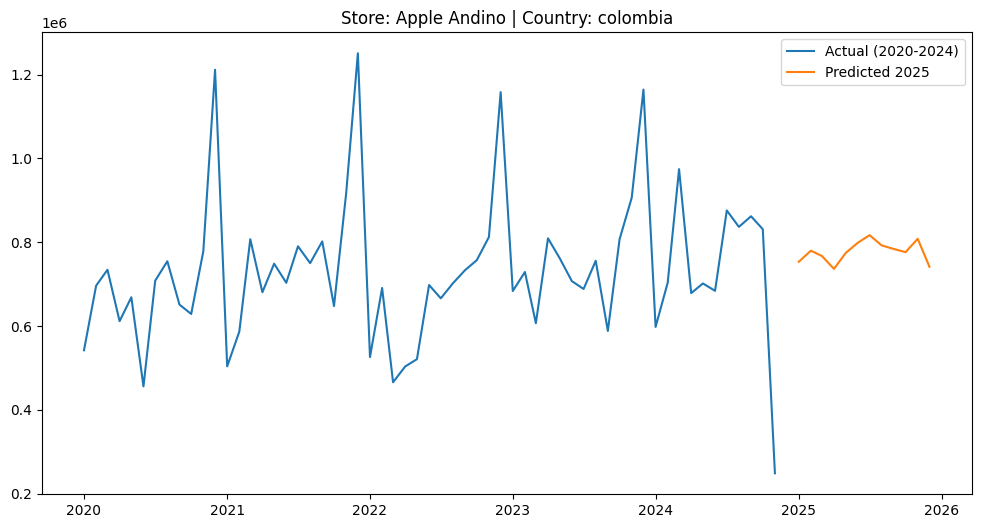

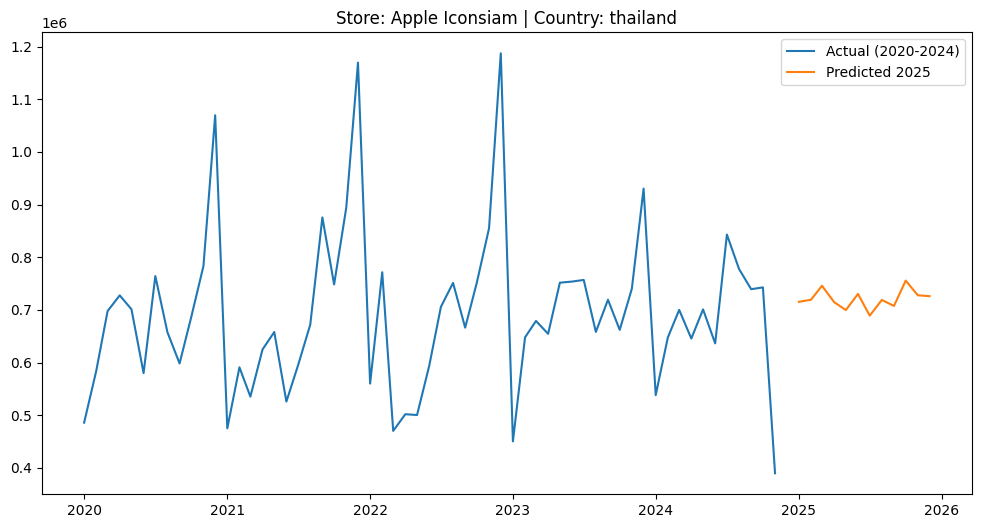

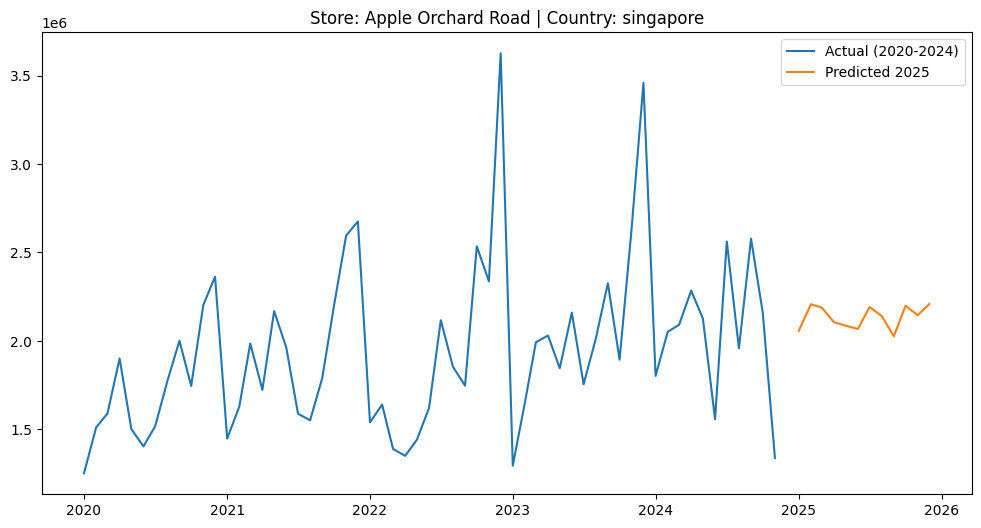

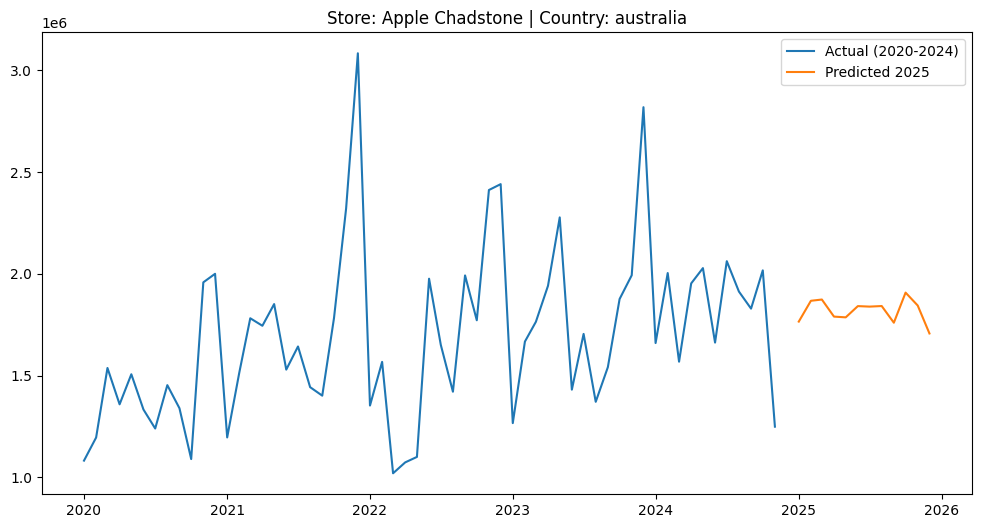

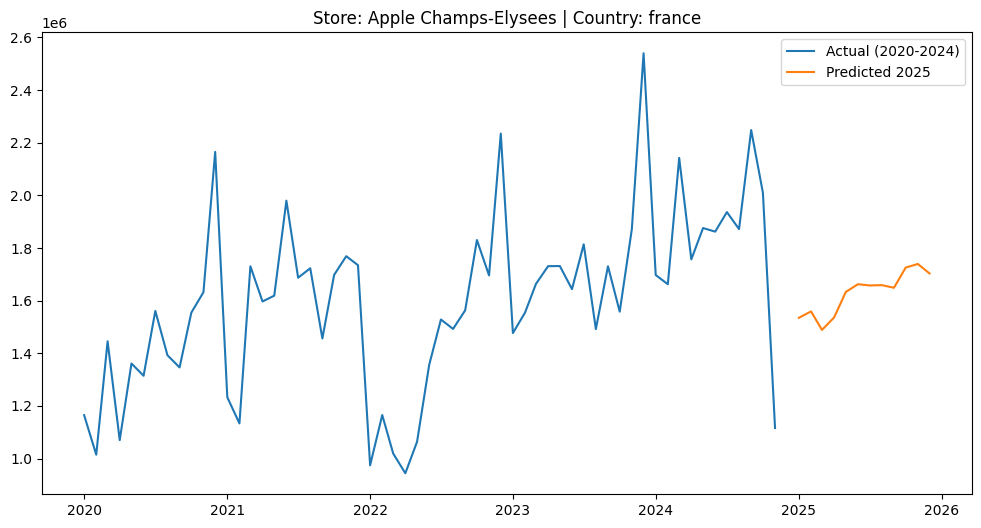

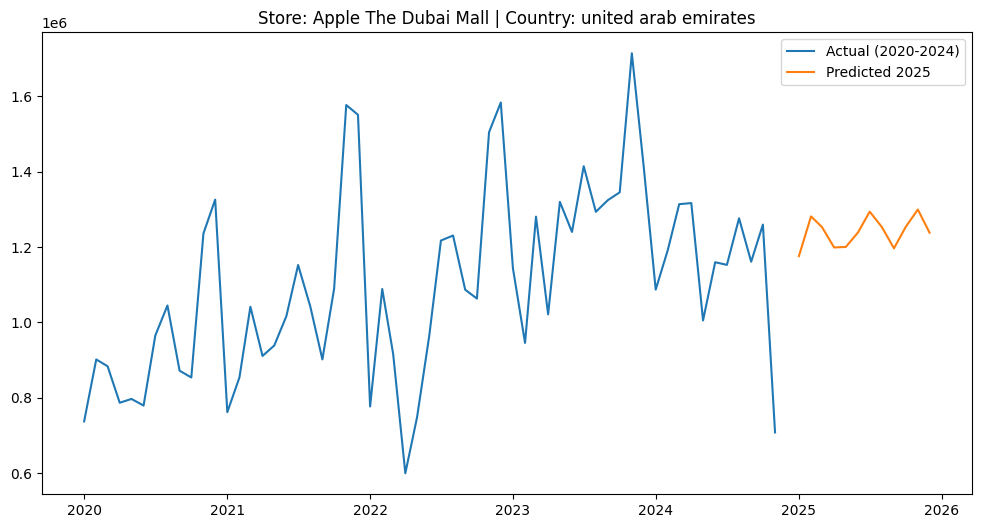

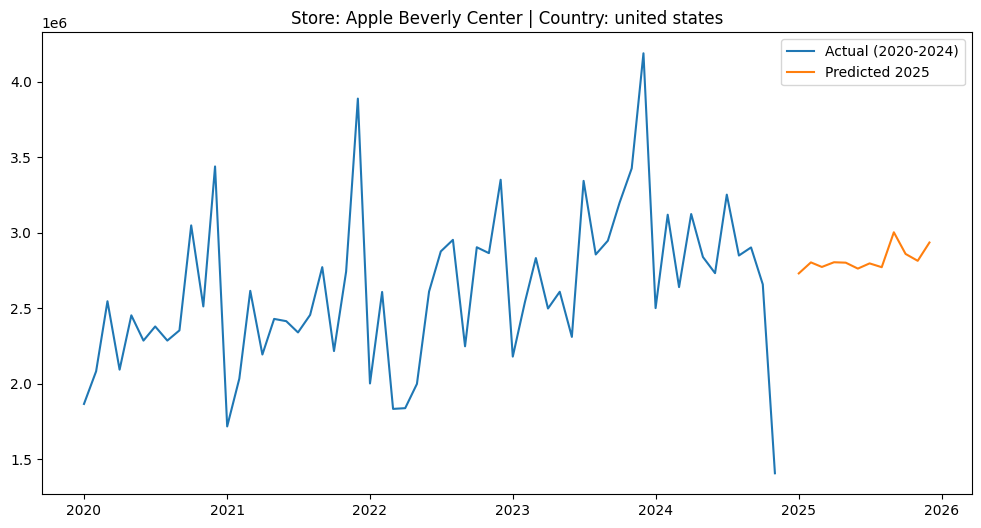

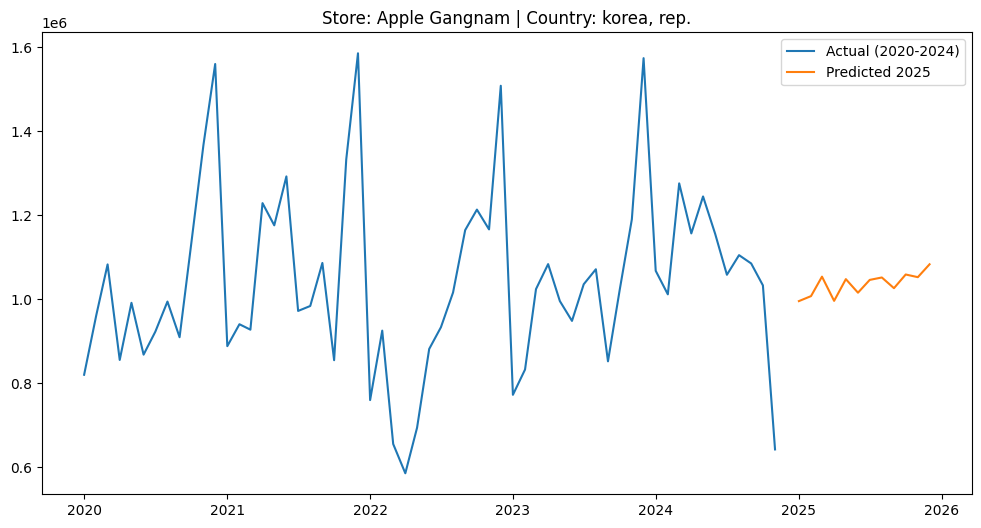

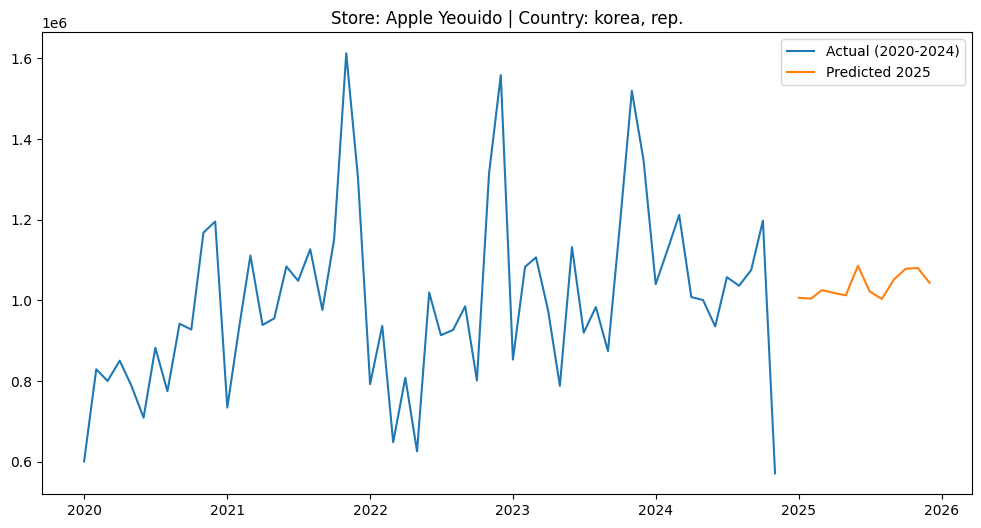

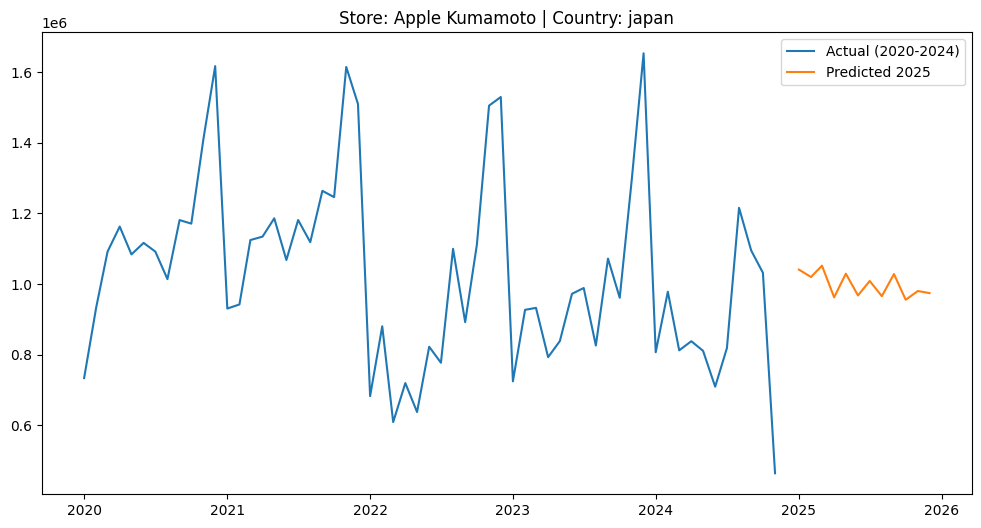

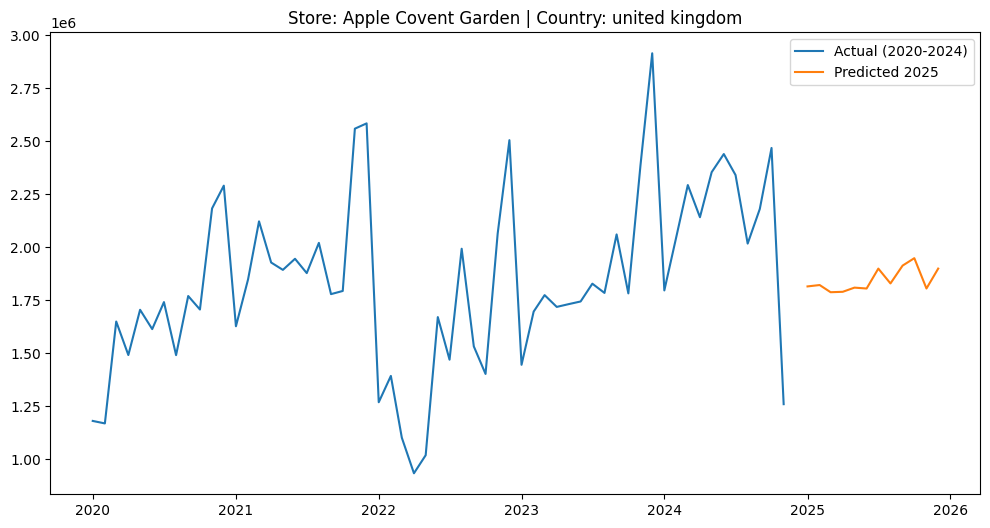

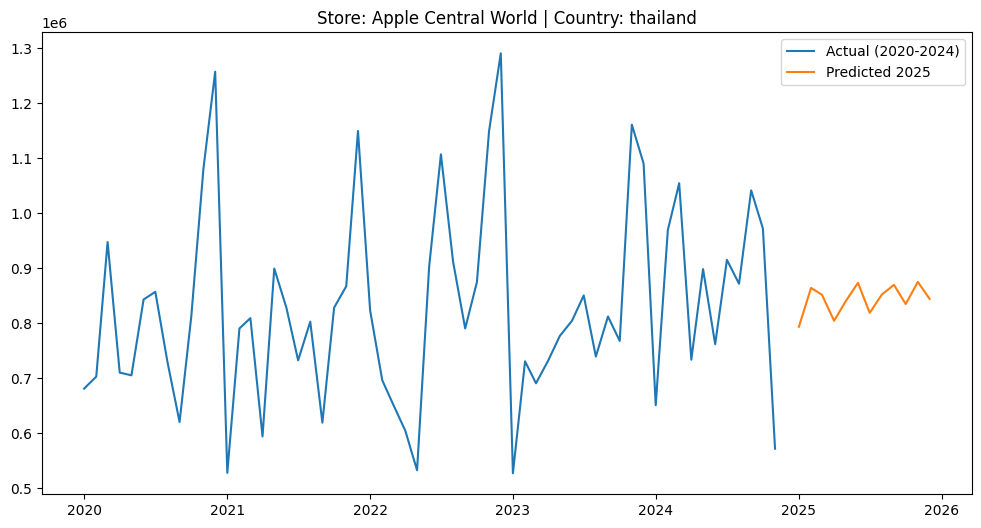

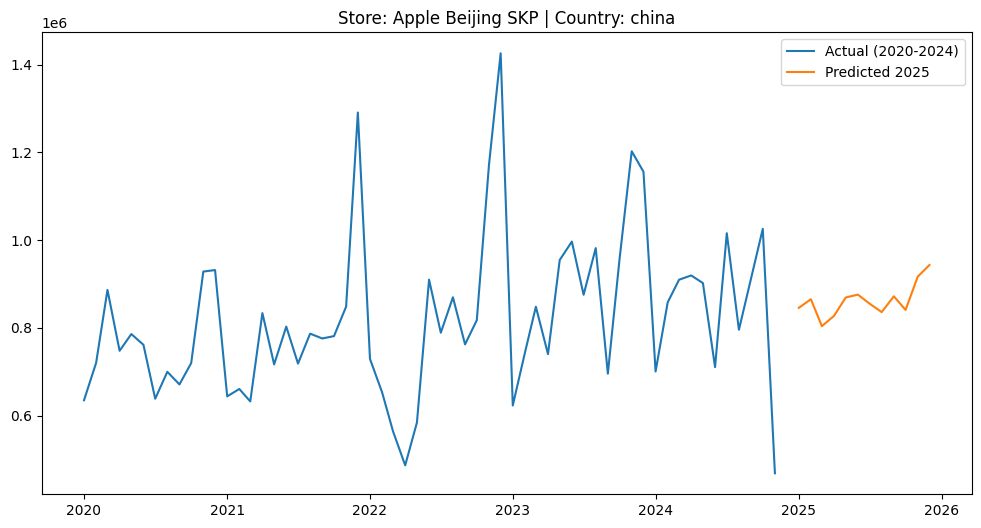

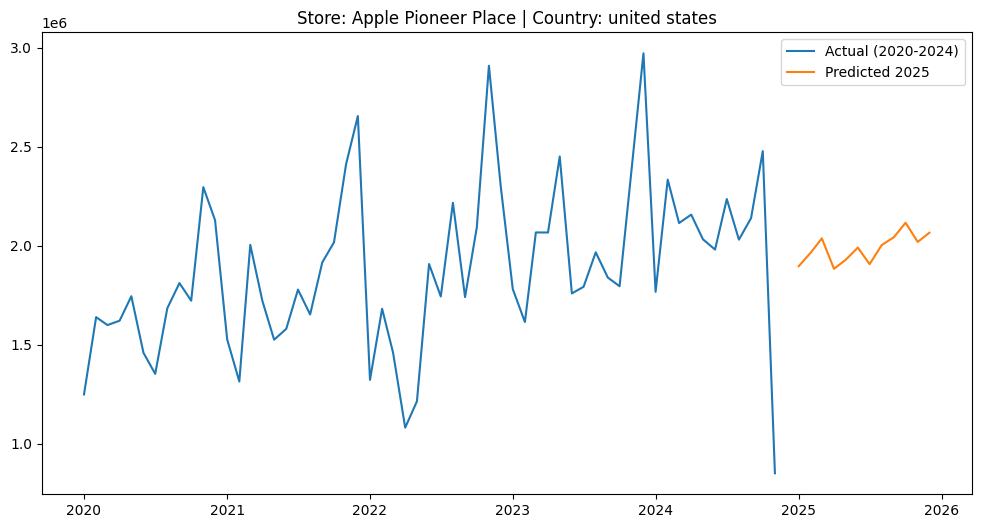

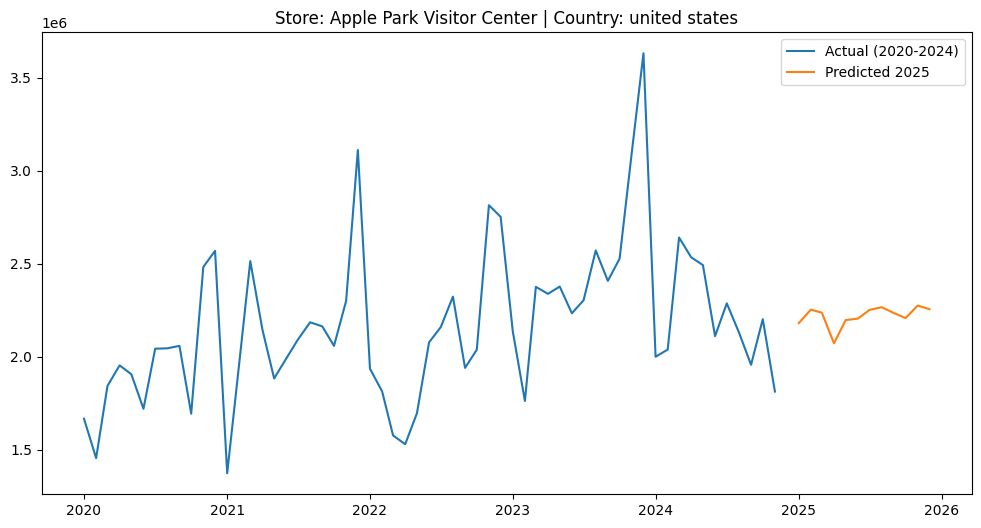

In [21]:
for store,(model,scaler,store_df,store_name,country) in store_results.items():

    data = store_df[[target]+features]

    scaled = scaler.transform(data)

    last_seq = scaled[-12:]

    last_seq = last_seq.reshape(1,12,len(features)+1)

    forecast_scaled = model(last_seq,training=False).numpy().flatten()

    dummy = np.zeros((12,len(features)+1))
    dummy[:,0]=forecast_scaled

    forecast = scaler.inverse_transform(dummy)[:,0]

    actual_dates = store_df["date"]
    actual = store_df[target]

    plt.figure(figsize=(12,6))

    plt.plot(actual_dates,actual,label="Actual (2020-2024)")

    plt.plot(future_dates,forecast,label="Predicted 2025")

    plt.title(f"Store: {store_name} | Country: {country}")

    plt.legend()

    plt.show()

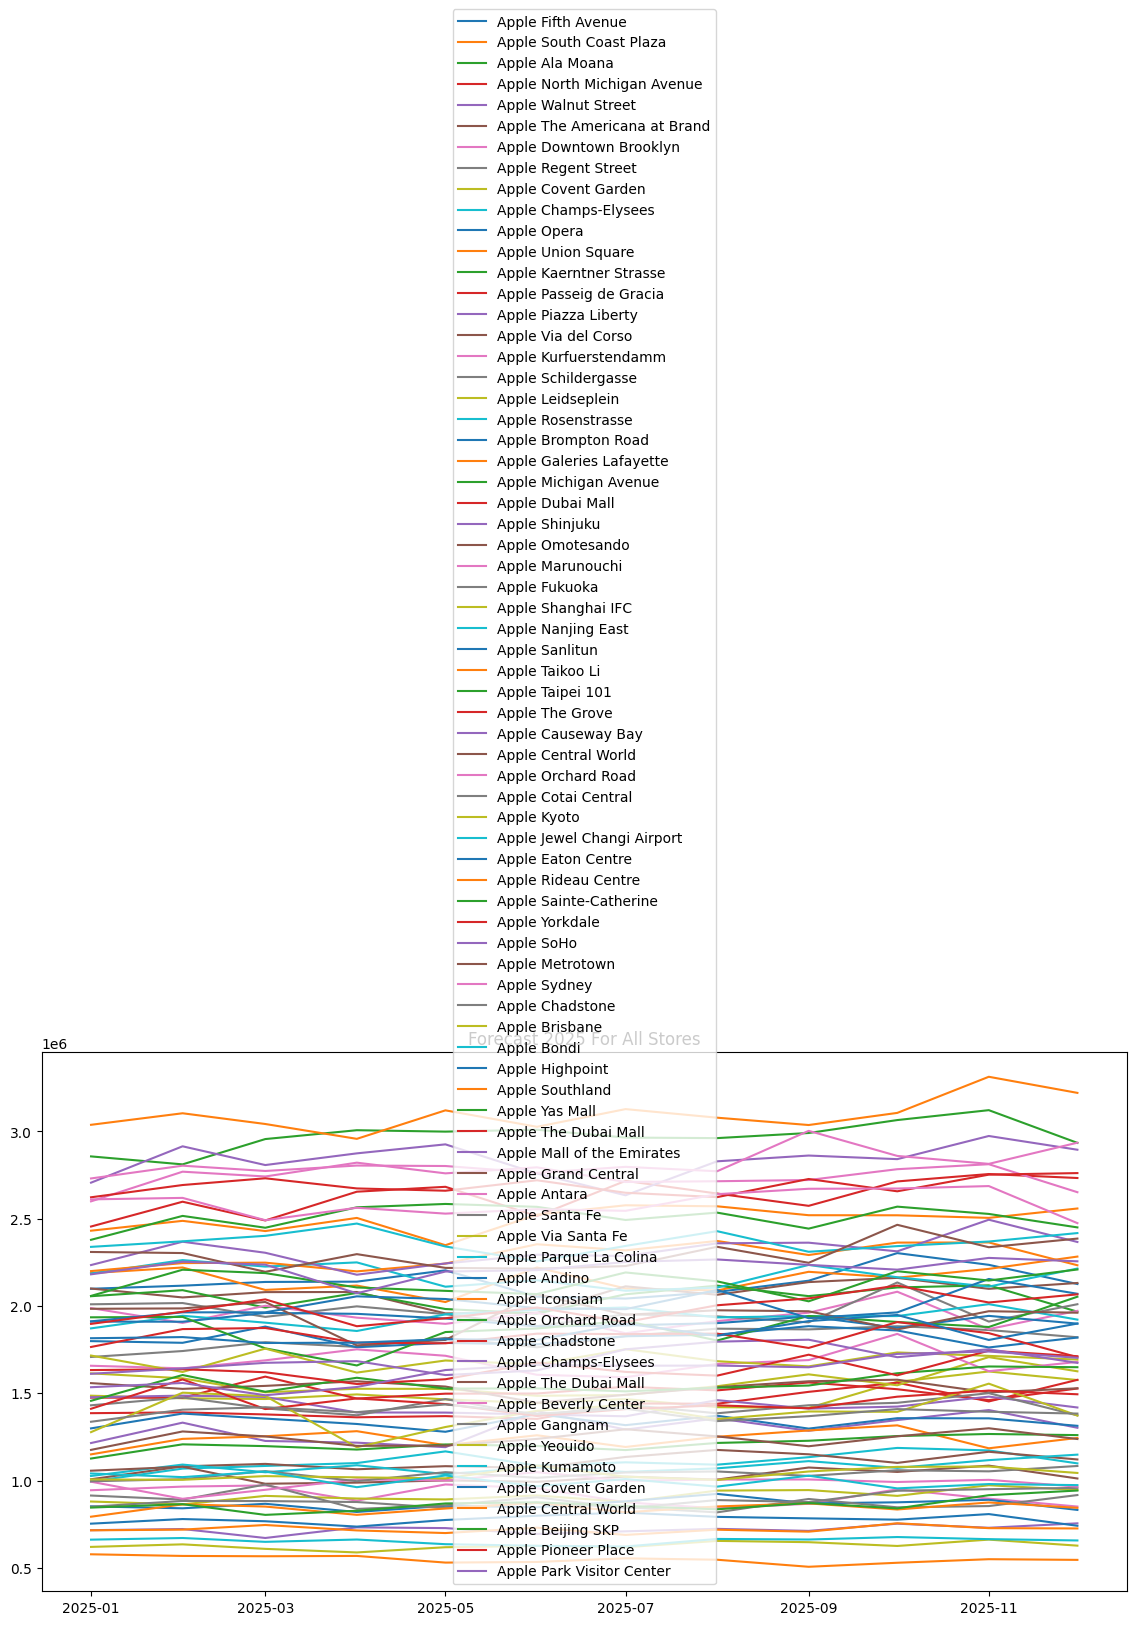

In [22]:
plt.figure(figsize=(14,7))

for store,(model,scaler,store_df,store_name,country) in store_results.items():

    data = store_df[[target]+features]

    scaled = scaler.transform(data)

    last_seq = scaled[-12:]

    last_seq = last_seq.reshape(1,12,len(features)+1)

    forecast_scaled = model(last_seq,training=False).numpy().flatten()

    dummy = np.zeros((12,len(features)+1))
    dummy[:,0]=forecast_scaled

    forecast = scaler.inverse_transform(dummy)[:,0]

    plt.plot(future_dates,forecast,label=store_name)

plt.title("Forecast 2025 For All Stores")

plt.legend()

plt.show()